Here we'll utilise Grad-CAM to visualize our model decisions boundries to understand them and observe why certain model fails at the given task.

In [1]:
import os
import struct
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
class my_dataset(Dataset):
    def __init__(self, root: str, train: bool = True, transform = None):

        self.root = root
        self.train = train
        self.transform = transform

        self.classes = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

        if train:
            image_path = "train-images-idx3-ubyte"
            label_path = "train-labels-idx1-ubyte"
        else:
            image_path = "t10k-images-idx3-ubyte"
            label_path = "t10k-labels-idx1-ubyte"

        self.img_path = os.path.join(root, image_path)
        self.lbl_path = os.path.join(root, label_path)

        self.samples = self._load_image(self.img_path)
        self.labels = self._load_label(self.lbl_path)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]

        if self.transform is not None:
            sample = self.transform(sample)

        if self.transform is None and not self.train:
            sample = sample.unsqueeze(0)

        return sample, label

    def _load_image(self, path):
        with open(path, "rb") as f:
            magic, no_of_samples, rows, cols = struct.unpack(">IIII", f.read(16))
            datas = f.read()

            samples = torch.tensor(list(datas), dtype = torch.float32)
            samples = samples/255.0
            samples = samples.reshape(no_of_samples, rows, cols)

        return samples

    def _load_label(self, path):
        with open(path, "rb") as f:
            magic, no_of_samples = struct.unpack(">II", f.read(8))
            datas = f.read()

            labels = torch.tensor(list(datas), dtype = torch.long)

        return labels

In [3]:
train_transform = torchvision.transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandAugment(num_ops = 2, magnitude = 9, num_magnitude_bins = 31),
    transforms.ToTensor()
])

In [4]:
root = Path(r"data/FashionMNIST/raw")

train_data = my_dataset(root, train = True, transform = train_transform)
test_data = my_dataset(root, train = False, transform = None)

train_sample, train_label = train_data[0]
test_sample, test_label = test_data[0]

train_sample.shape, train_data.classes[train_label.item()], test_sample.shape, test_data.classes[test_label.item()]

(torch.Size([1, 28, 28]), 'Ankle boot', torch.Size([1, 28, 28]), 'Ankle boot')

In [5]:
def my_gradcam(model: torch.nn.Module, data_sample, target, device: torch.device):
    model = model.to(device)
    img, label = data_sample
    sample = img.to(device)

    classes = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

    activation_map = {}
    gradients = {}

    def forward_hook(module, input, output):
        activation_map['value'] = output

    def backward_hook(module, grad_input, grad_output):
        gradients['value'] = grad_output[0]

    def min_max_normalize(data):
        data = data - data.min()
        data = data / (data.max() + 1e-8)
        return data

    forward_handel = target.register_forward_hook(forward_hook)
    backward_handel = target.register_full_backward_hook(backward_hook)

    try:
        model.eval()
        y_pred = model(sample)
    
        pred_class_idx = y_pred.argmax(dim = 1).item()
        pred_label = classes[pred_class_idx]

        model.zero_grad()
        score = y_pred[0, pred_class_idx]
        score.backward()

        activation_map_values = activation_map['value']
        gradients_values = gradients['value']

        alpha = torch.mean(gradients_values, dim = (2,3), keepdim = True)
        gradients_weighted = alpha * activation_map_values

        cam = torch.sum(gradients_weighted, dim = 1, keepdim = True)
        cam = torch.nn.functional.relu(cam)

        upscaled_cam = torch.nn.functional.interpolate(cam, size = (28, 28), mode = 'bilinear', align_corners = False)

        normalised_cam = min_max_normalize(upscaled_cam)

        heatmap_overlay = normalised_cam.squeeze().detach().cpu().numpy()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        axes[0].imshow(sample.squeeze().detach().cpu().numpy(), cmap='gray')
        axes[0].set_title(f"Original\nTrue: {classes[label]}")
        axes[0].axis('off')
        
        axes[1].imshow(heatmap_overlay, cmap='jet')
        axes[1].set_title(f"Grad-CAM\nTarget: {pred_label}")
        axes[1].axis('off')
        
        axes[2].imshow(sample.squeeze().detach().cpu().numpy(), cmap='gray')
        axes[2].imshow(heatmap_overlay, cmap='jet', alpha=0.5)
        axes[2].set_title("Overlay")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

    finally:
        forward_handel.remove()
        backward_handel.remove()

lets define and load our 1k model and the best deep model.

In [6]:
class my_1K_model(torch.nn.Module):
    def __init__(self, in_channels, no_of_kernels, no_of_classes):
        super().__init__()

        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = in_channels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d( p = 0.2)
        )

        self.block2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d( p = 0.2)
        )

        self.classifierblock = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Dropout(p = 0.5),
            torch.nn.Linear(in_features = no_of_kernels * 7 * 7, out_features = no_of_classes)
        )

    def forward(self, x):
        return(self.classifierblock(self.block2(self.block1(x))))

In [7]:
class my_best_CNN_model(torch.nn.Module):
    def __init__(self, input_channels, no_of_class):
        super().__init__()

        self.layers = torch.nn.Sequential(

            torch.nn.Conv2d(input_channels, 32, kernel_size = 3, stride = 1, padding = 1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),

            torch.nn.Conv2d(32, 32, kernel_size = 3, stride = 1, padding = 1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d(p = 0.1),

            torch.nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),

            torch.nn.Conv2d(64, 64, kernel_size = 3, padding = 1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(2),
            torch.nn.Dropout2d(p = 0.1),

            torch.nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU()
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128*7*7, 128),
            torch.nn.ReLU(),
            
            torch.nn.Dropout(p = 0.2),

            torch.nn.Linear(128, no_of_class)
        )

    def forward(self, x):
        return self.classifier(self.layers(x))

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
model_1k = my_1K_model(1, 10, len(test_data.classes))
best_model = my_best_CNN_model(1, len(test_data.classes))

In [10]:
model_1k

my_1K_model(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.2, inplace=False)
  )
  (classifierblock): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [11]:
summary(
    model = model_1k,
    input_size = (1, 1, 28, 28)
)

Layer (type:depth-idx)                   Output Shape              Param #
my_1K_model                              [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 10, 28, 28]           100
│    └─ReLU: 2-2                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 10, 28, 28]           910
│    └─ReLU: 2-4                         [1, 10, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 10, 14, 14]           --
│    └─Dropout2d: 2-6                    [1, 10, 14, 14]           --
├─Sequential: 1-2                        [1, 10, 7, 7]             --
│    └─Conv2d: 2-7                       [1, 10, 14, 14]           910
│    └─ReLU: 2-8                         [1, 10, 14, 14]           --
│    └─MaxPool2d: 2-9                    [1, 10, 7, 7]             --
│    └─Dropout2d: 2-10                   [1, 10, 7, 7]             --
├─Sequential

In [12]:
best_model

my_best_CNN_model(
  (layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [13]:
summary(
    model = best_model,
    input_size = (1, 1, 28, 28)
)

Layer (type:depth-idx)                   Output Shape              Param #
my_best_CNN_model                        [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─Conv2d: 2-4                       [1, 32, 28, 28]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 28, 28]           64
│    └─ReLU: 2-6                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-7                    [1, 32, 14, 14]           --
│    └─Dropout2d: 2-8                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-9                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-10                 [1, 64, 14, 14]           128
│    └─ReLU: 2-11                        [1, 64, 14, 14]           --
│    └

In [14]:
model_1k_path = r'models/cnn_1k_model.pth'
best_model_path = r'models/better_cnn_model.pth'

In [15]:
model_1k.load_state_dict(torch.load(f = model_1k_path))

<All keys matched successfully>

In [16]:
best_model.load_state_dict(torch.load(f = best_model_path))

<All keys matched successfully>

lets make prediction usin 1k model and visualise its decision logic using gradcam

In [17]:
target_1k = model_1k.block2[0]
target_best = best_model.layers[16]


In [18]:
def get_random_test_data():
    img, lbl = test_data[np.random.randint(0, len(test_data))]
    img = img.unsqueeze(0)

    data = (img, lbl)

    return data

In [19]:
test_data_1 = get_random_test_data()
img, lbl = test_data_1

img.shape, lbl.item()

(torch.Size([1, 1, 28, 28]), 1)

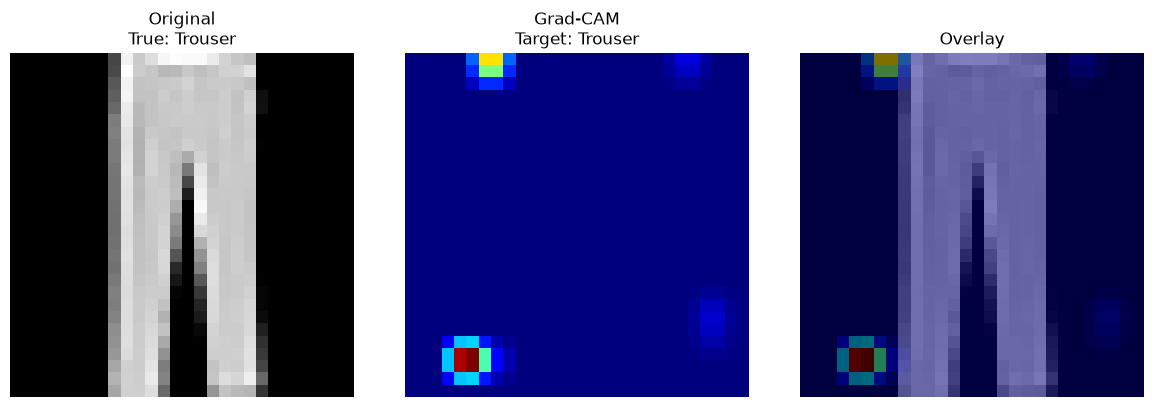

In [20]:
my_gradcam(
    model = model_1k,
    data_sample = test_data_1,
    target = target_1k,
    device = device
)

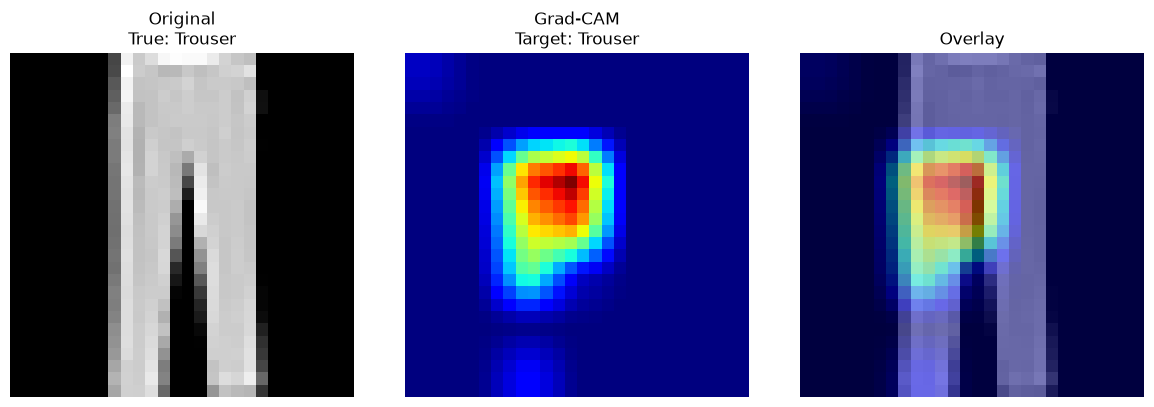

In [21]:
my_gradcam(
    model = best_model,
    data_sample = test_data_1,
    target = target_best,
    device = device
)

In [22]:
test_data_2 = get_random_test_data()

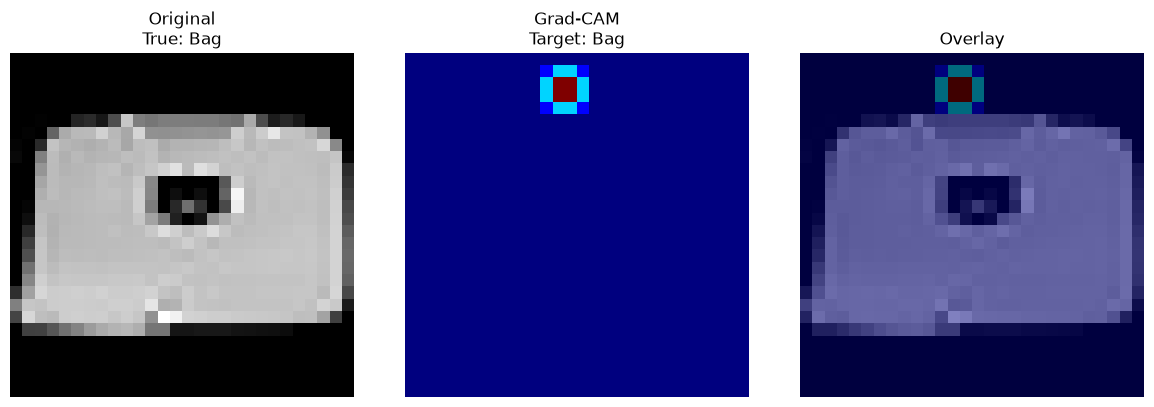

In [23]:
my_gradcam(
    model = model_1k,
    data_sample = test_data_2,
    target = target_1k,
    device = device
)

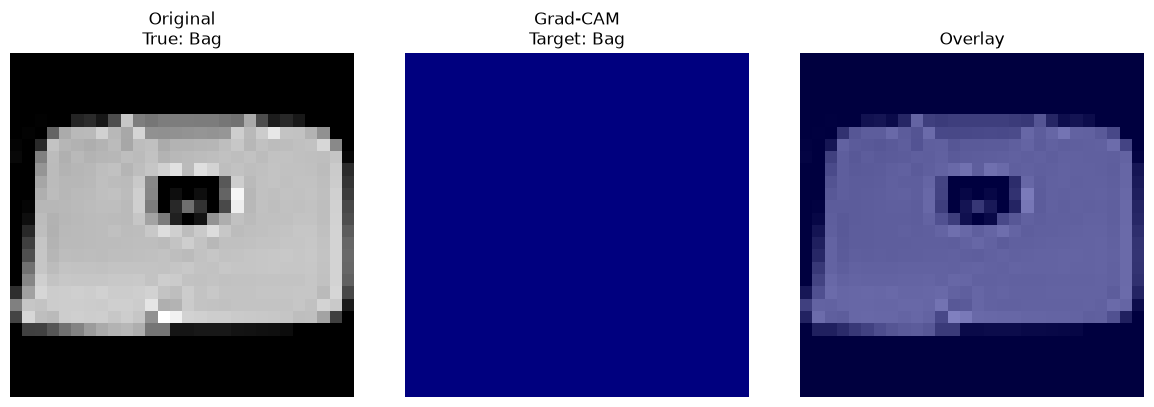

In [24]:
my_gradcam(
    model = best_model,
    data_sample = test_data_2,
    target = target_best,
    device = device
)

In [25]:
test_data_3 = get_random_test_data()

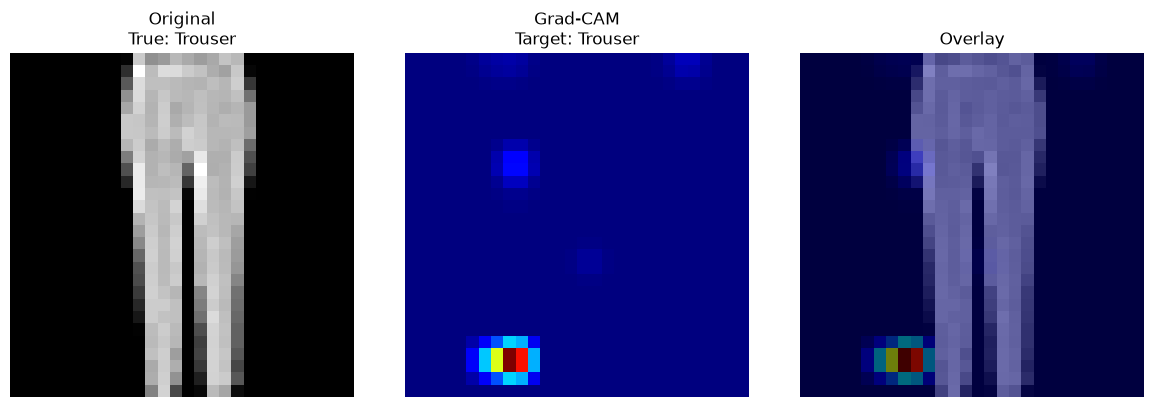

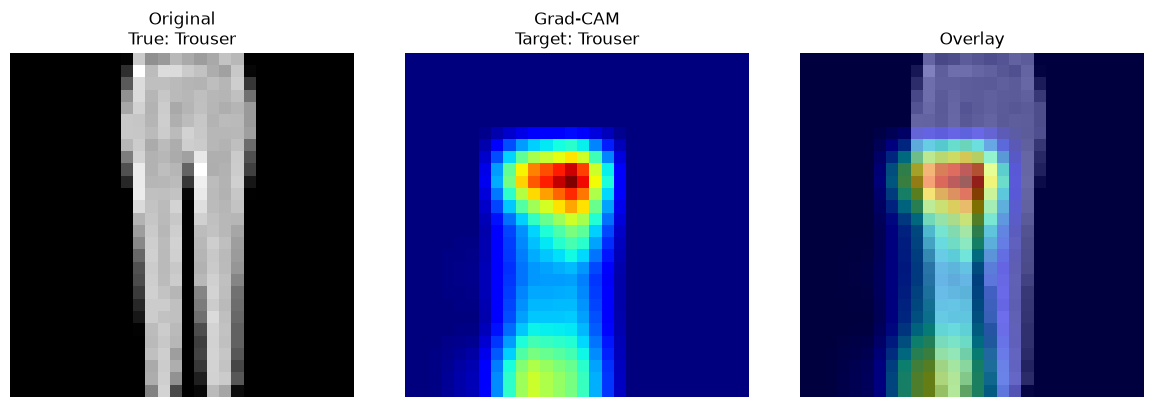

In [26]:
my_gradcam(
    model = model_1k,
    data_sample = test_data_3,
    target = target_1k,
    device = device
)

my_gradcam(
    model = best_model,
    data_sample = test_data_3,
    target = target_best,
    device = device
)

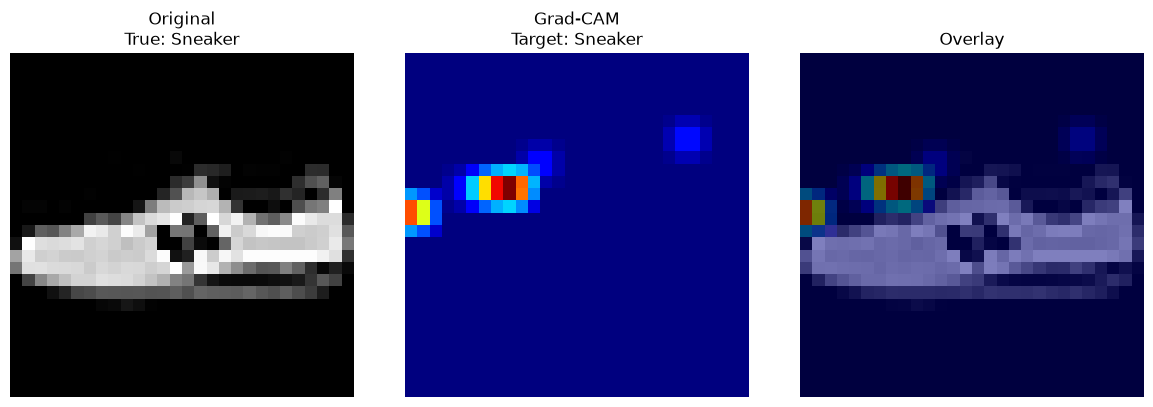

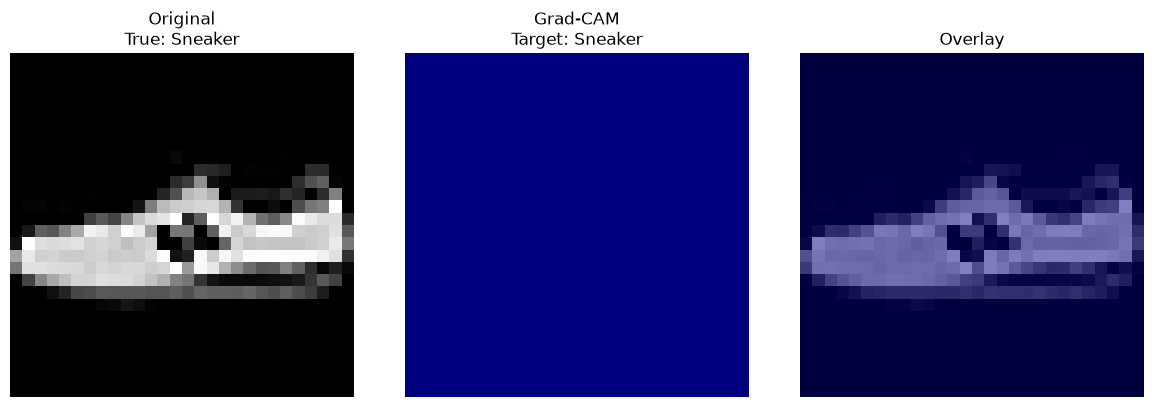

In [27]:
td = get_random_test_data()

my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)

my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

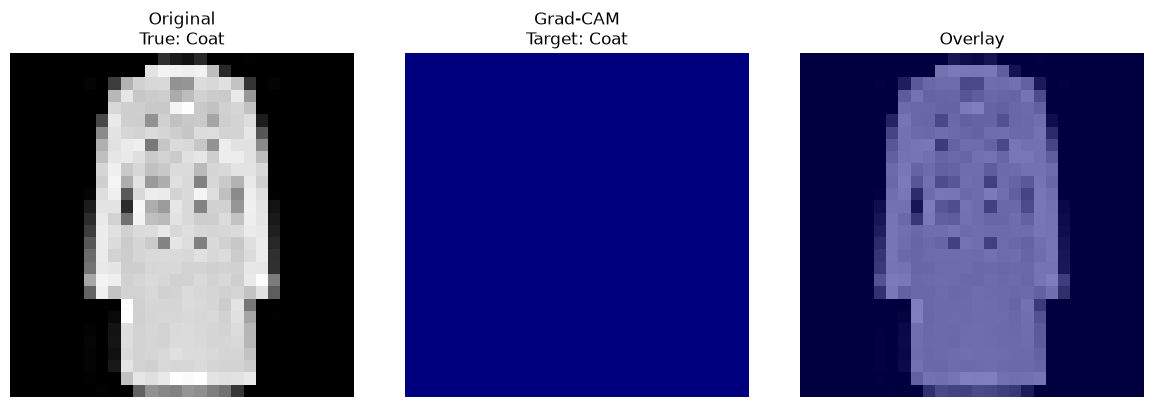

In [28]:
td = get_random_test_data()

my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)


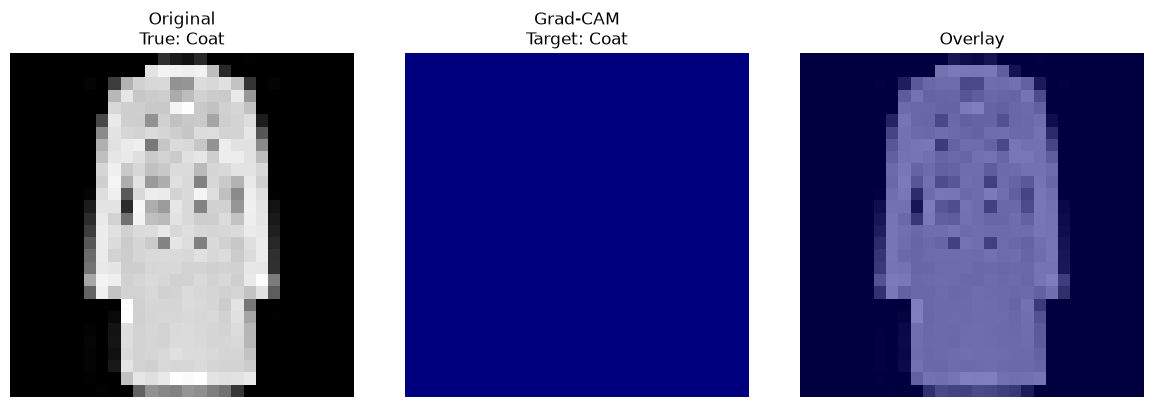

In [29]:
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


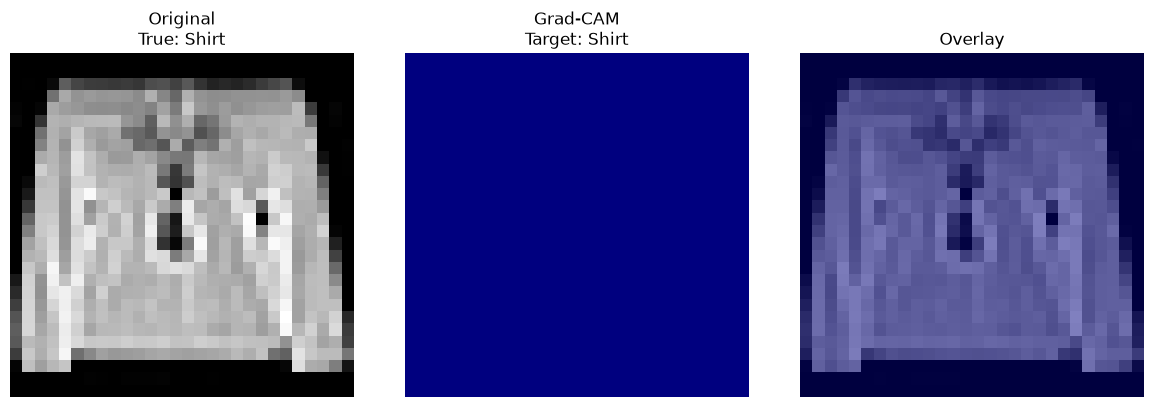

best model


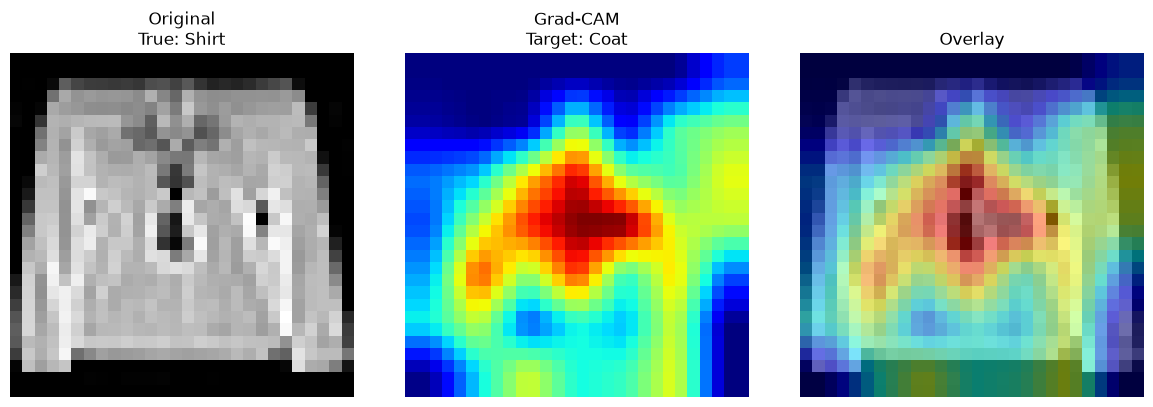

In [30]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


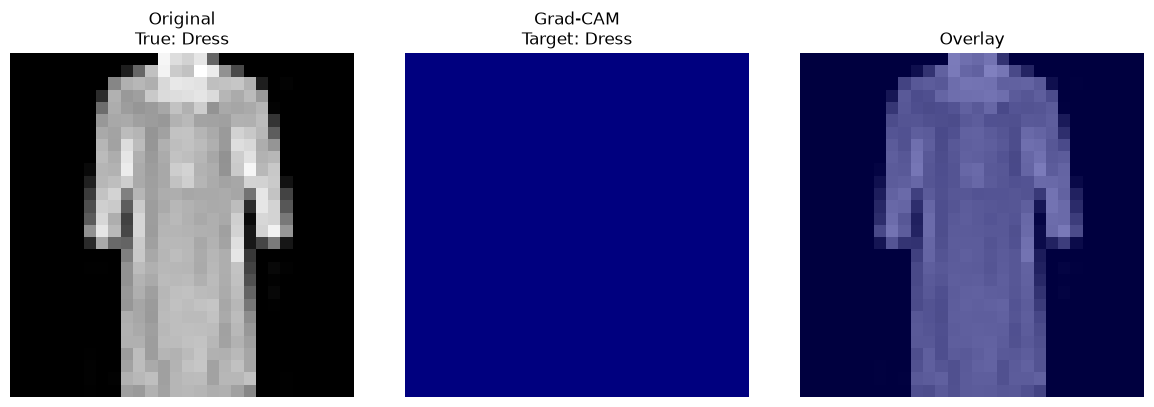

best model


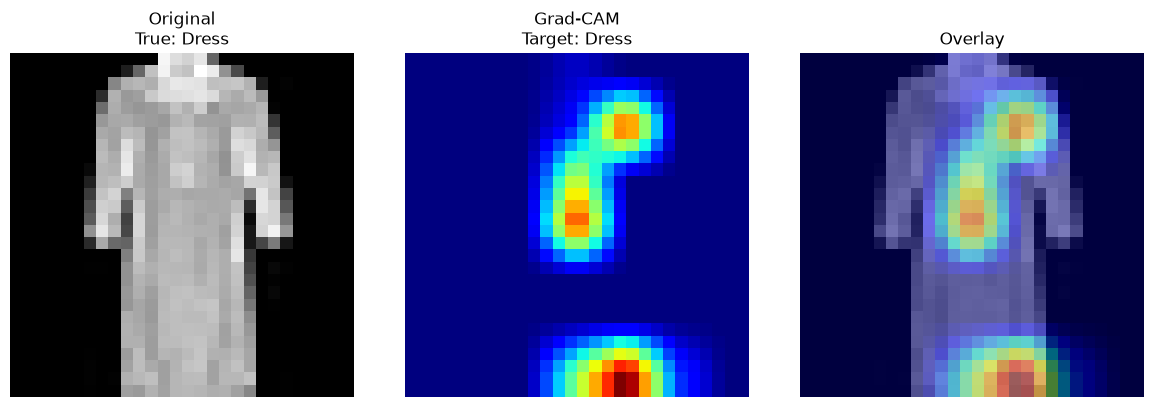

In [31]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


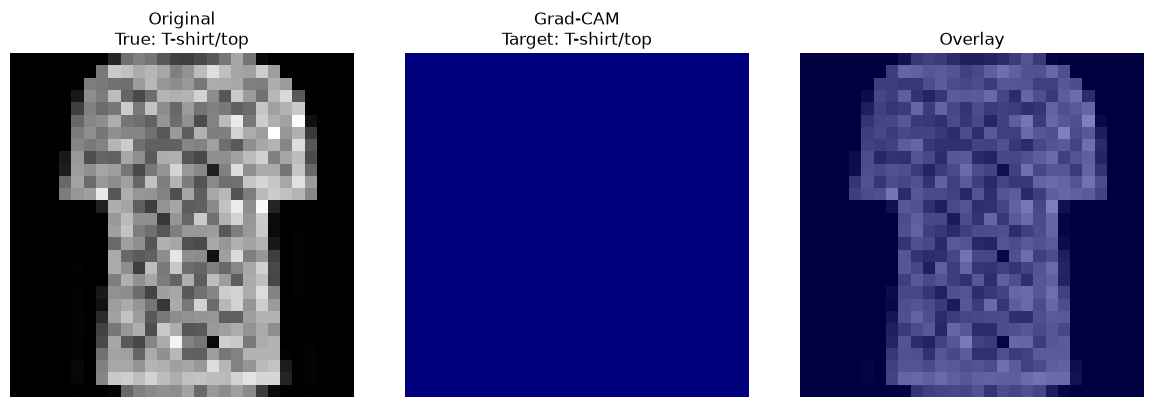

best model


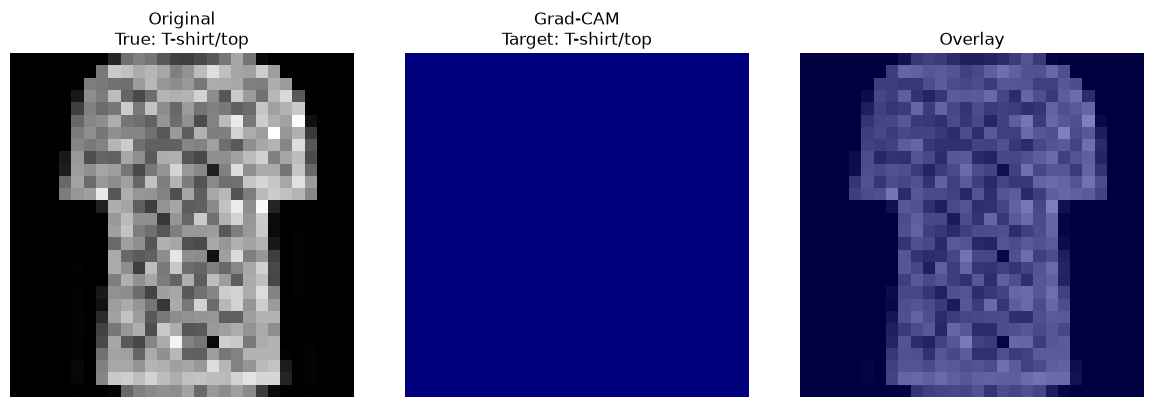

In [32]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


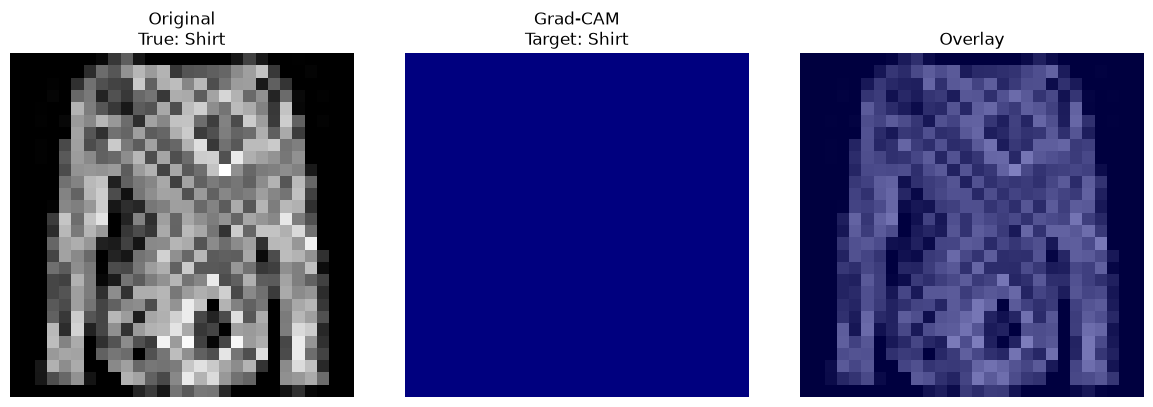

best model


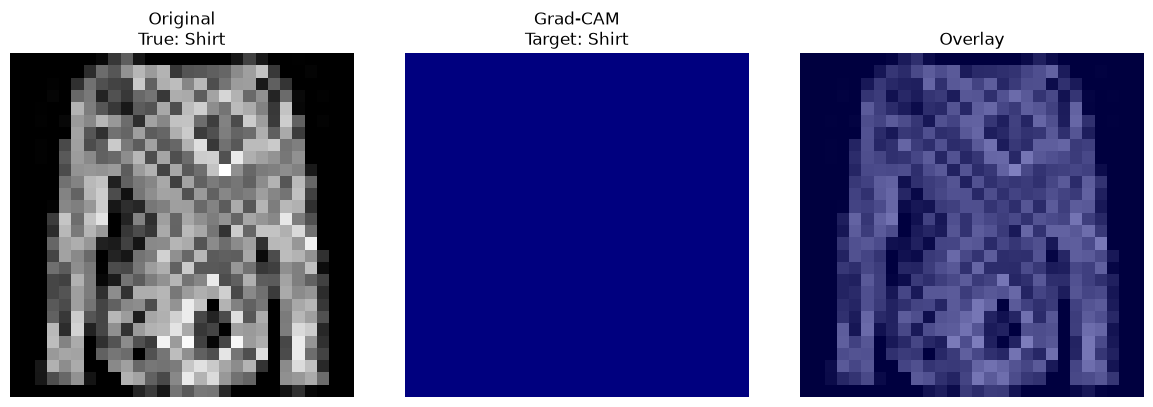

In [33]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


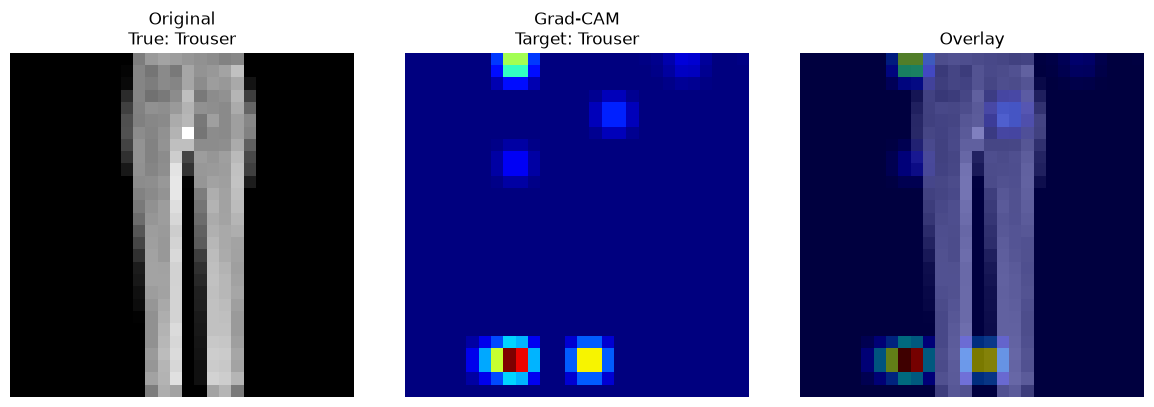

best model


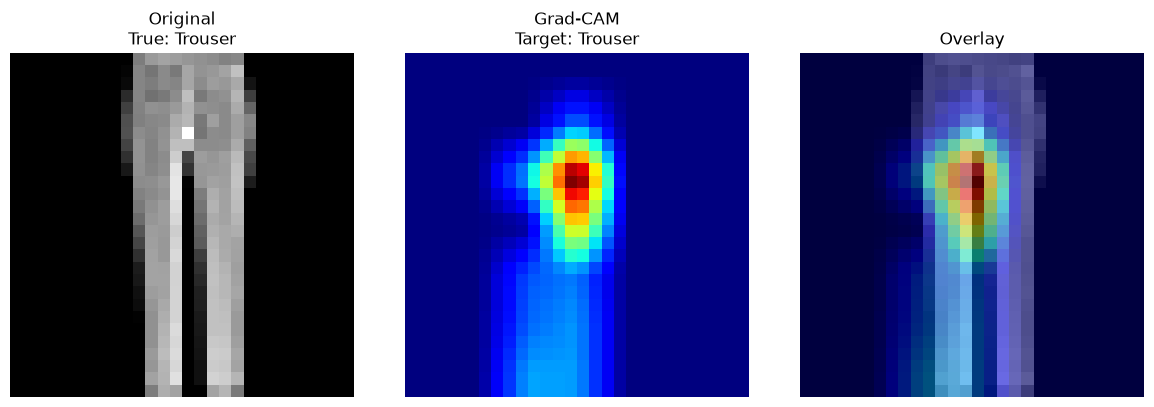

In [34]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


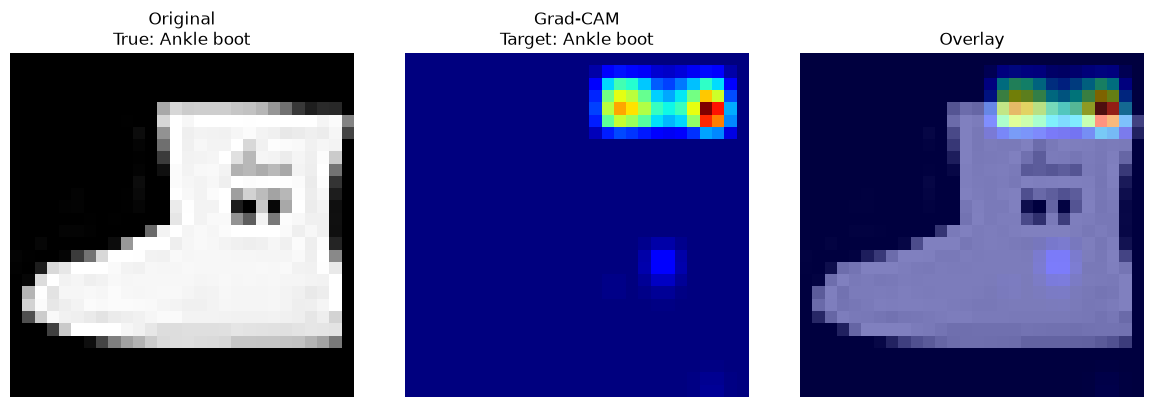

best model


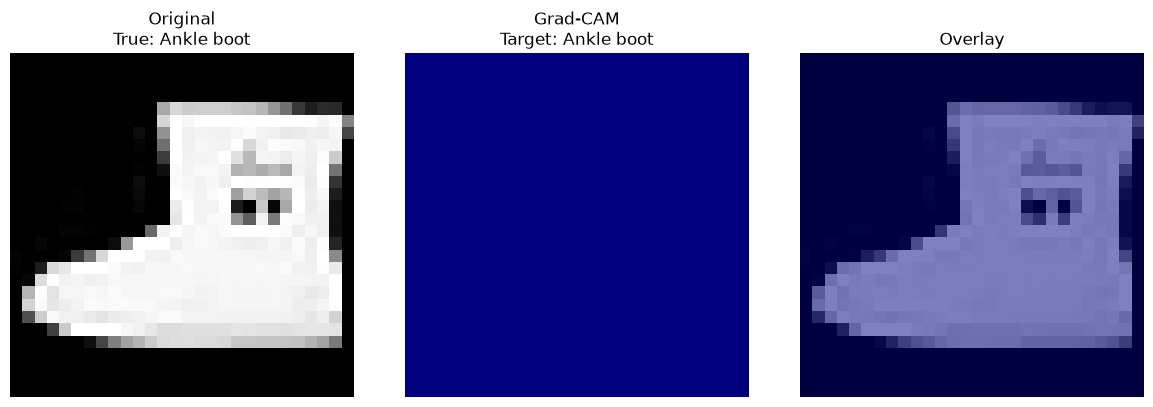

In [35]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


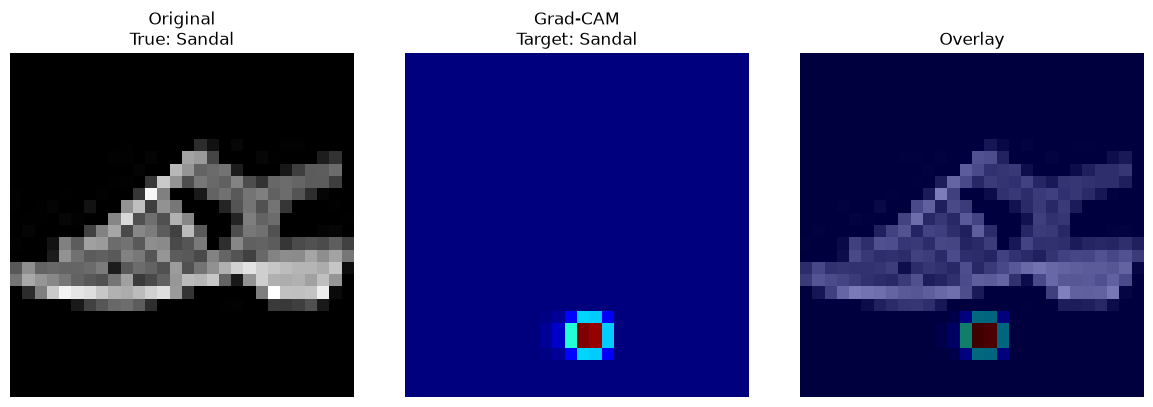

best model


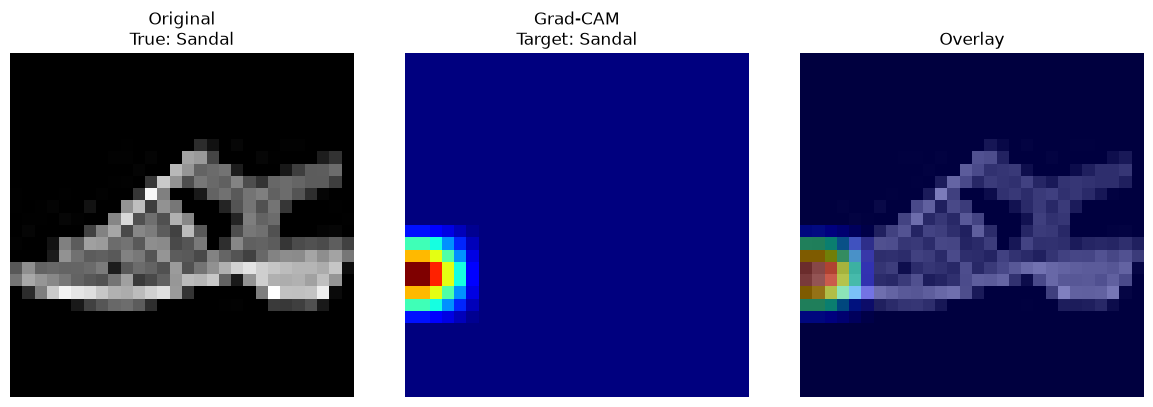

In [36]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


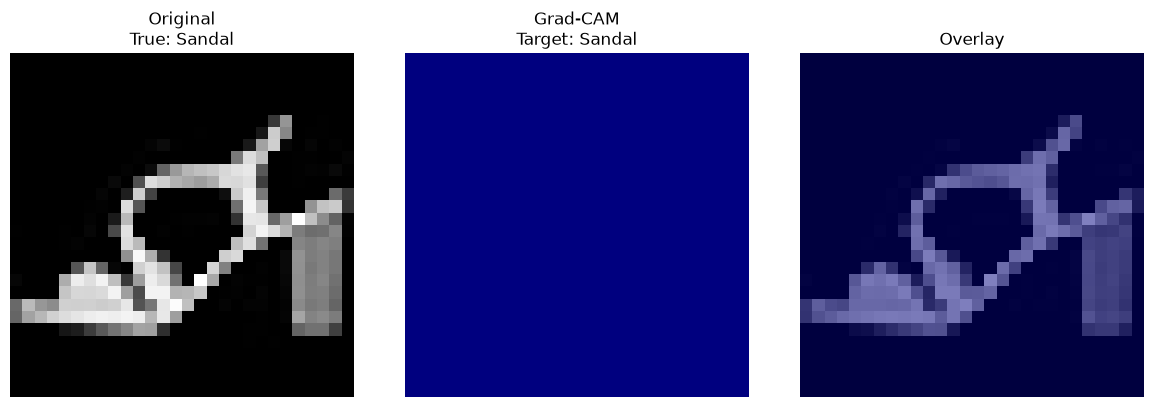

best model


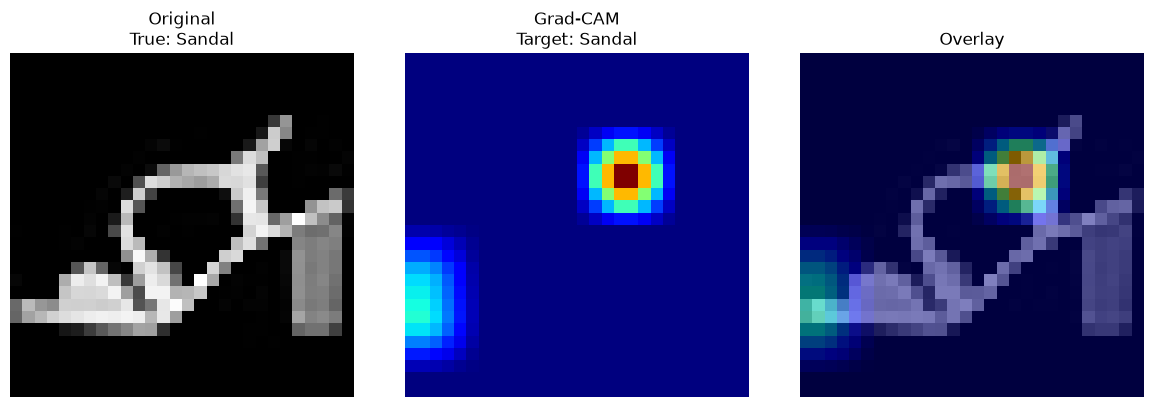

In [37]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


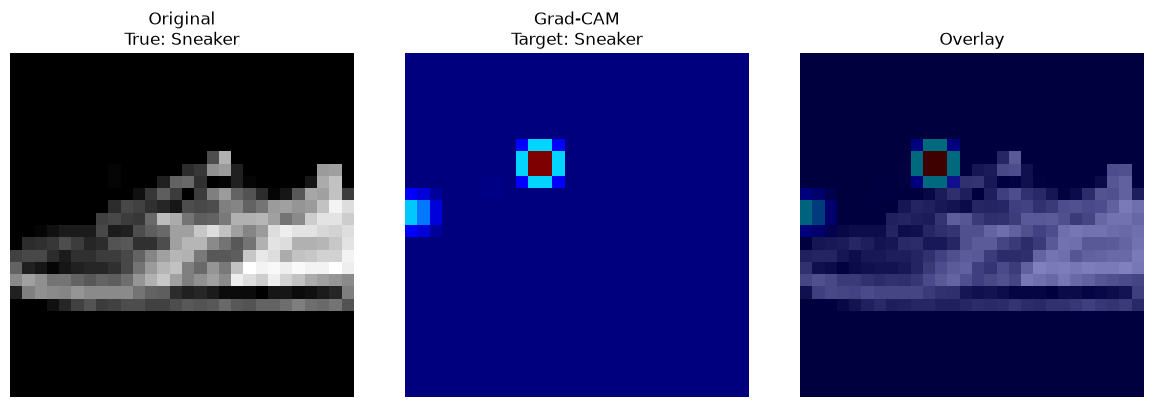

best model


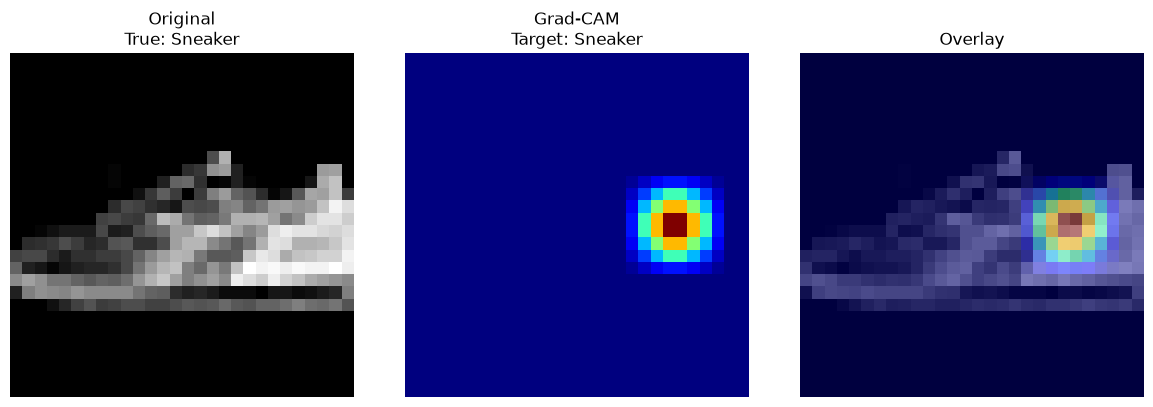

In [38]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


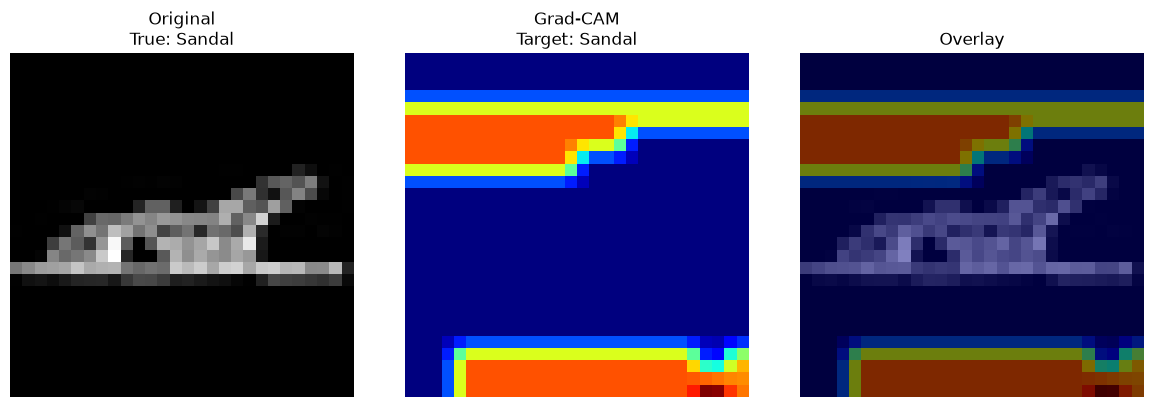

best model


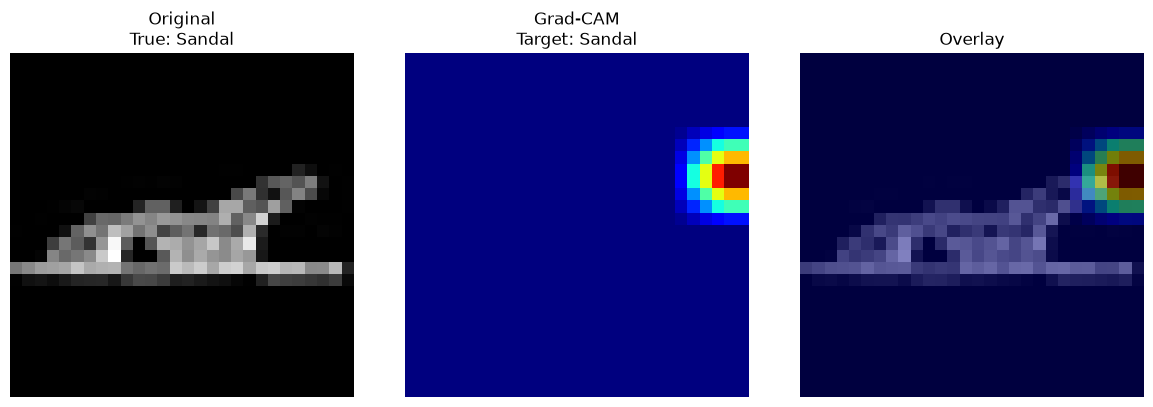

In [39]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


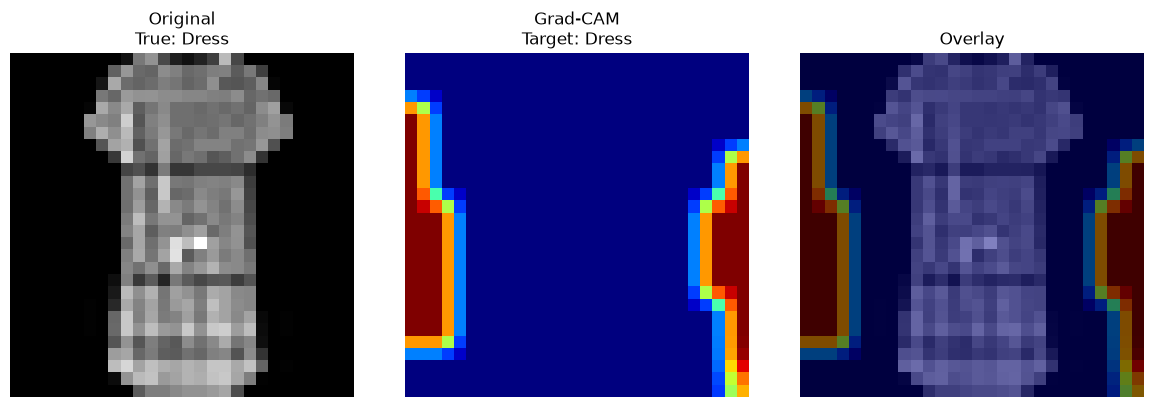

best model


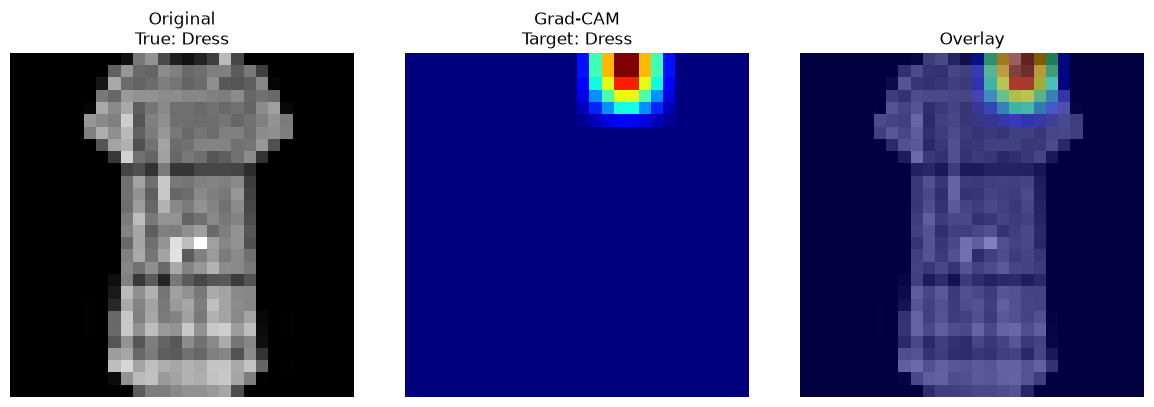

In [40]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


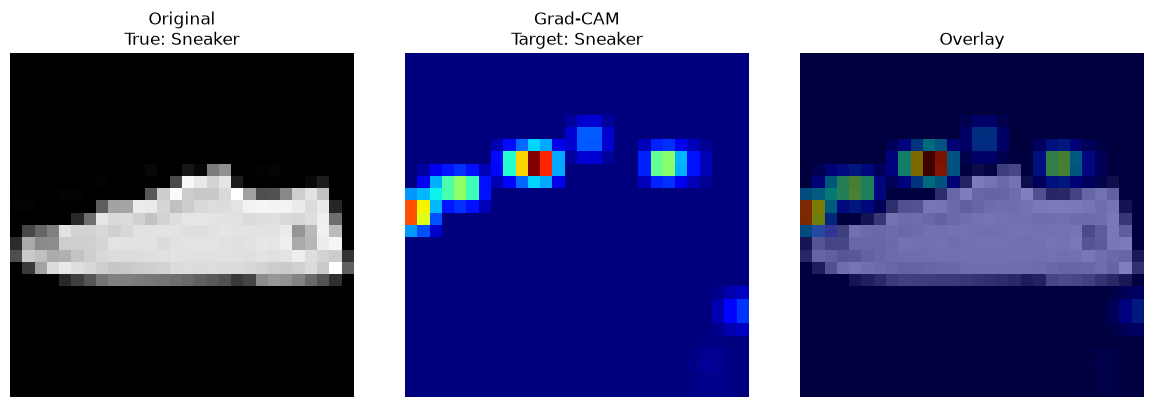

best model


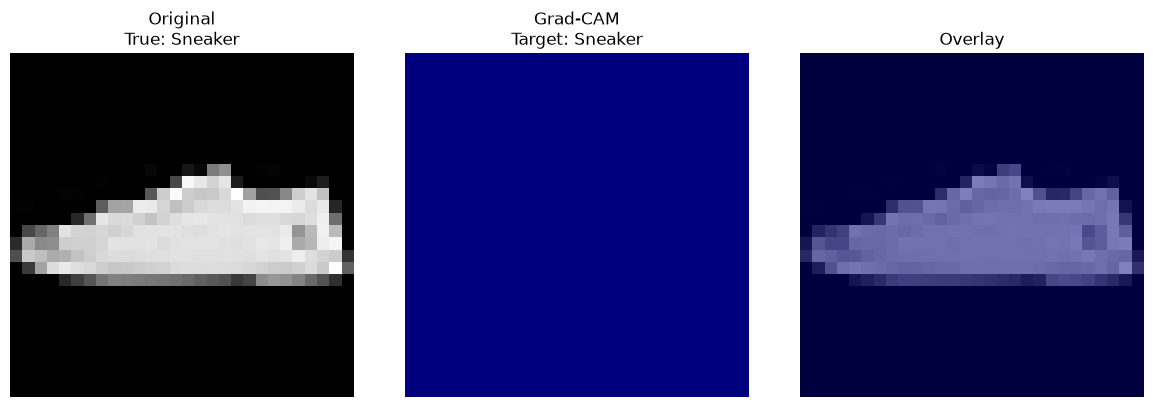

In [41]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


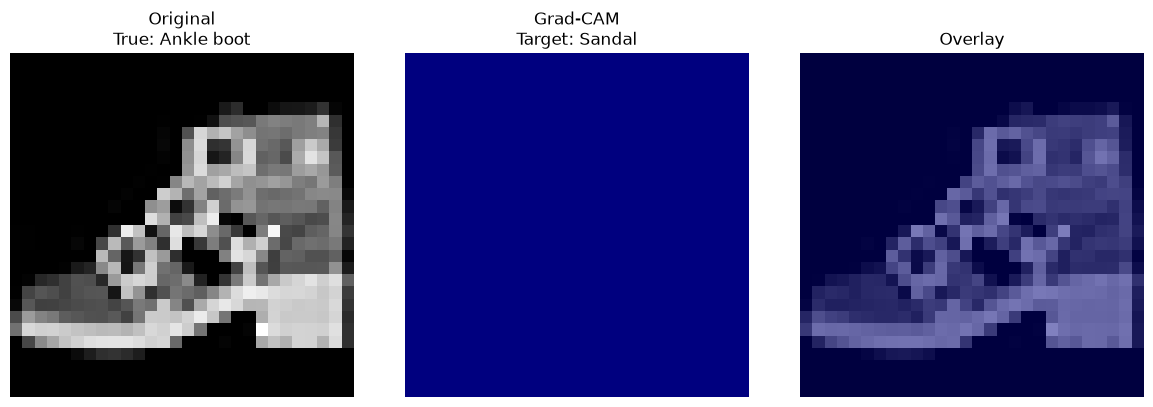

best model


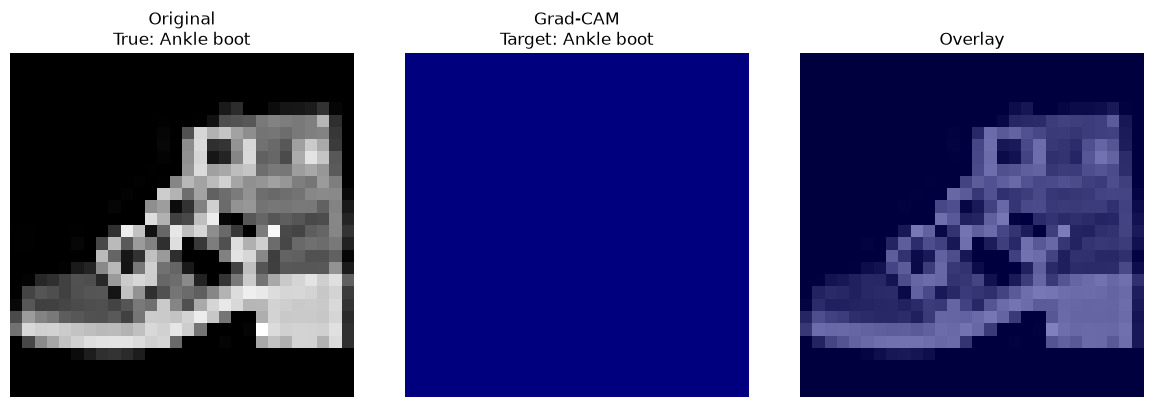

In [42]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


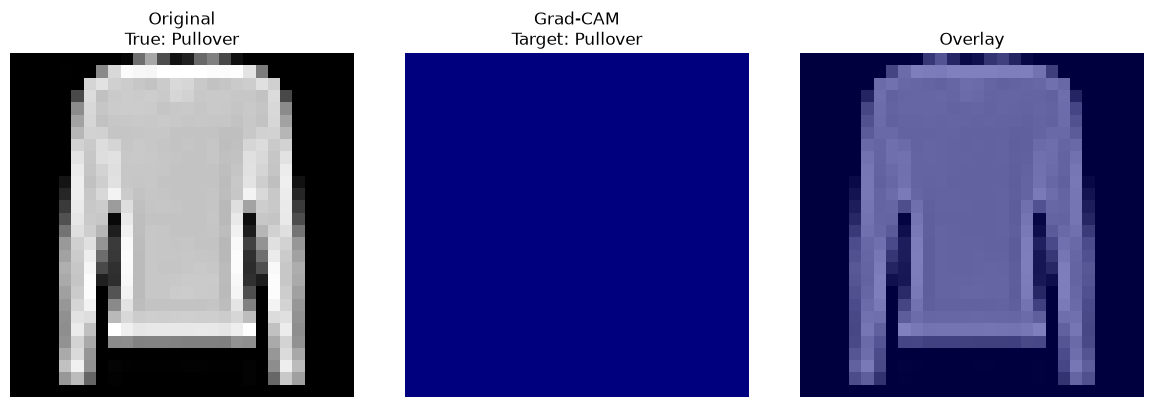

best model


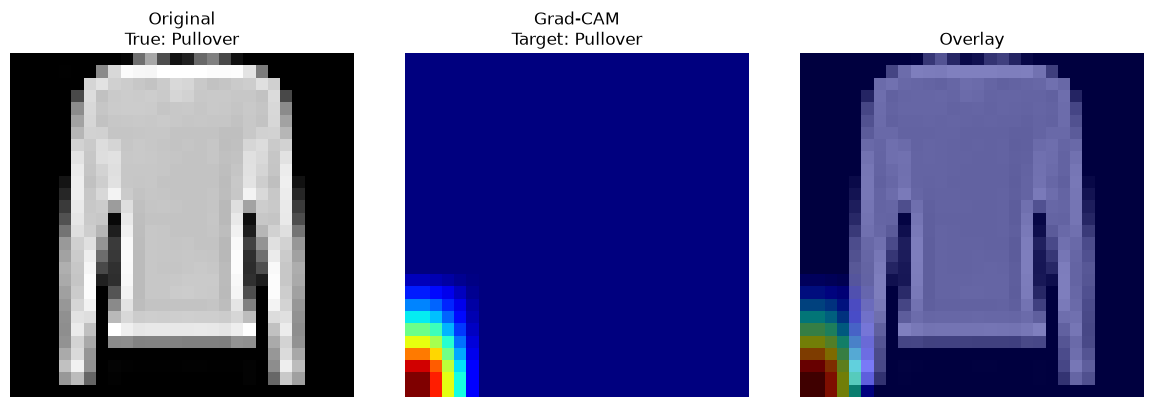

In [43]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


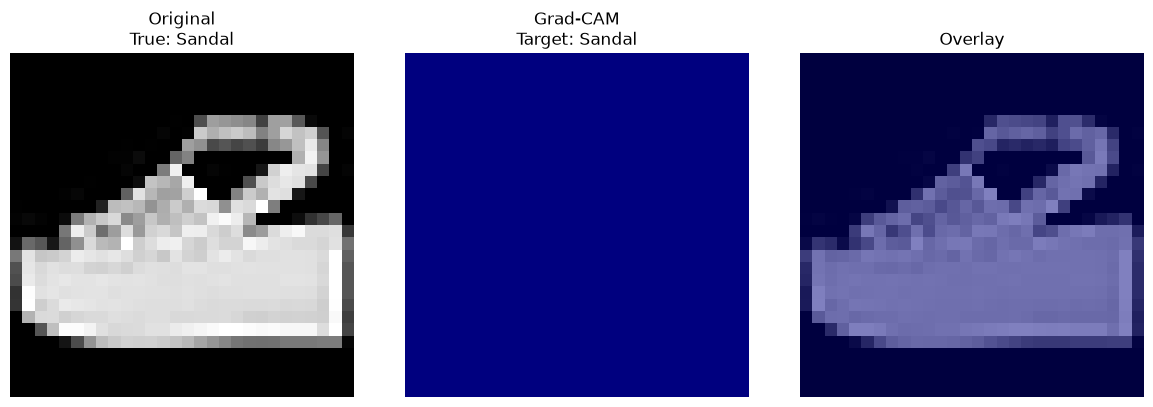

best model


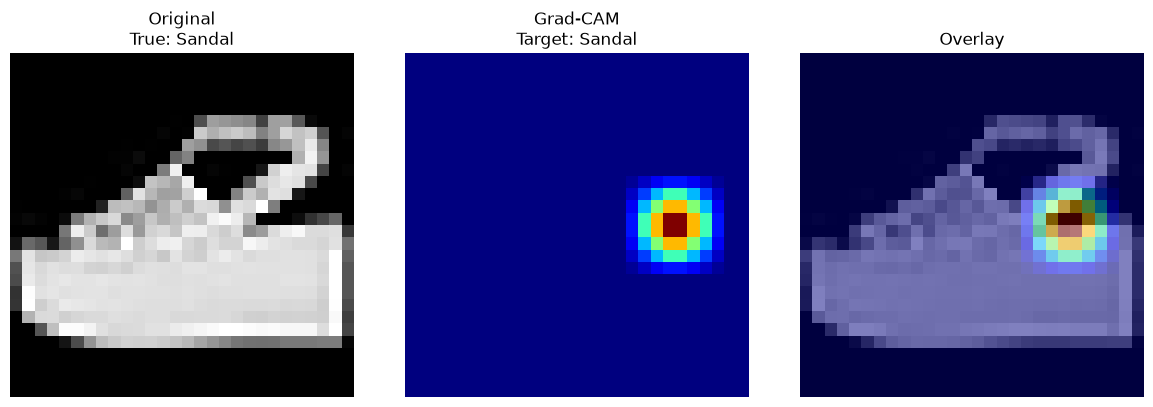

In [44]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


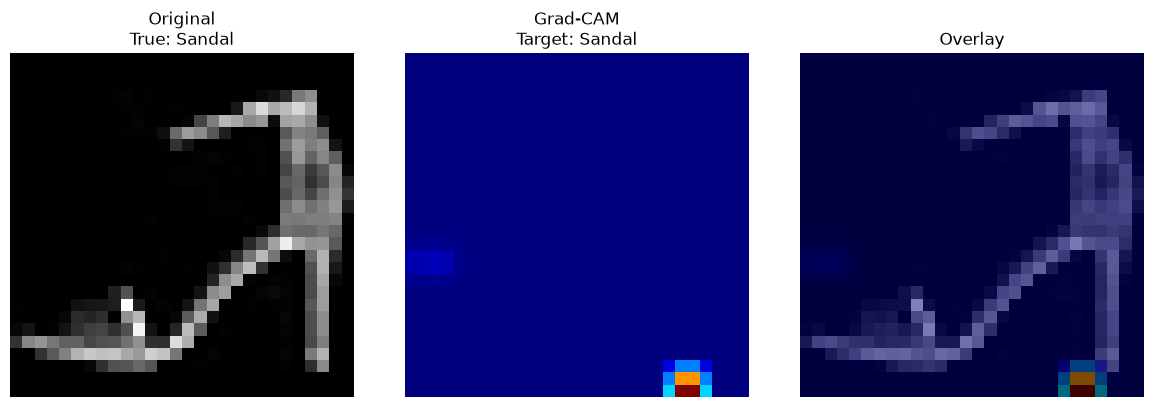

best model


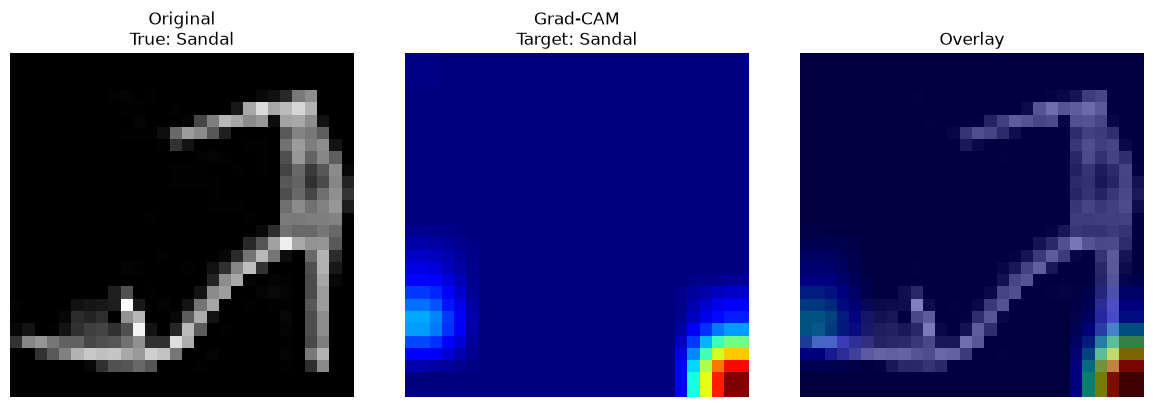

In [45]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


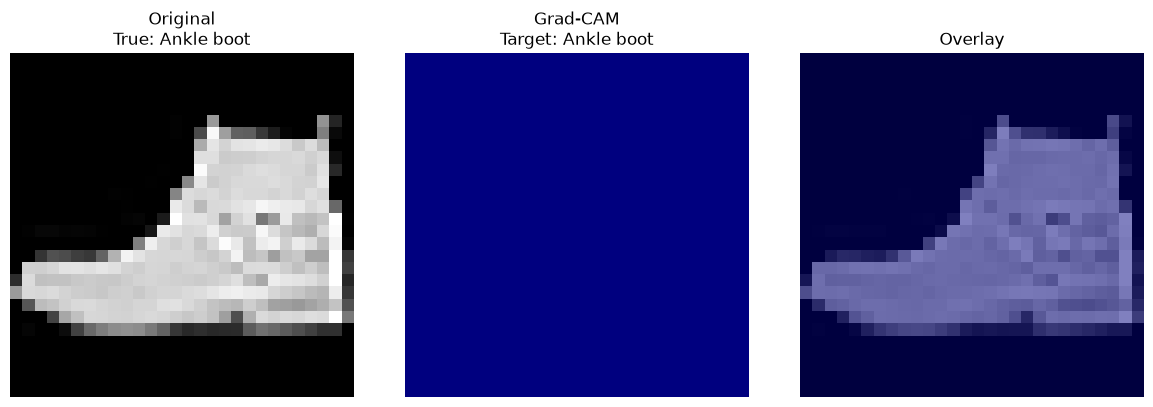

best model


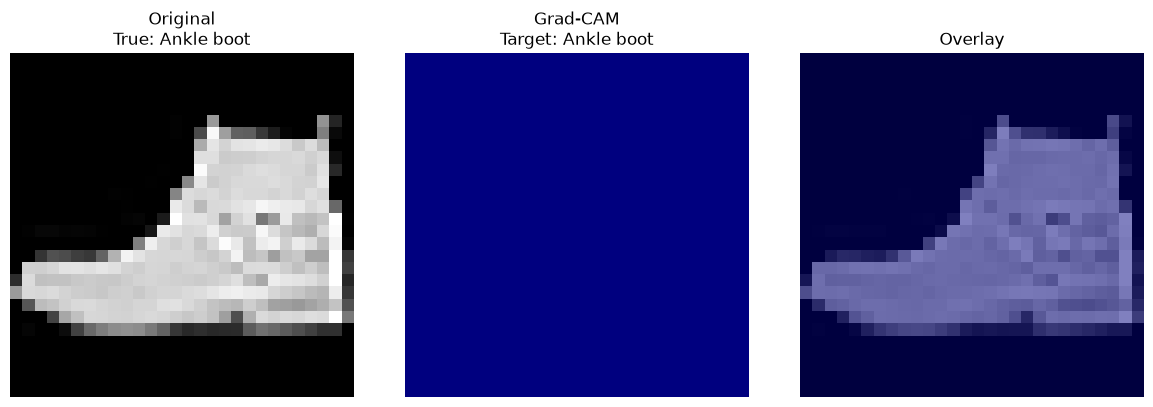

In [46]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


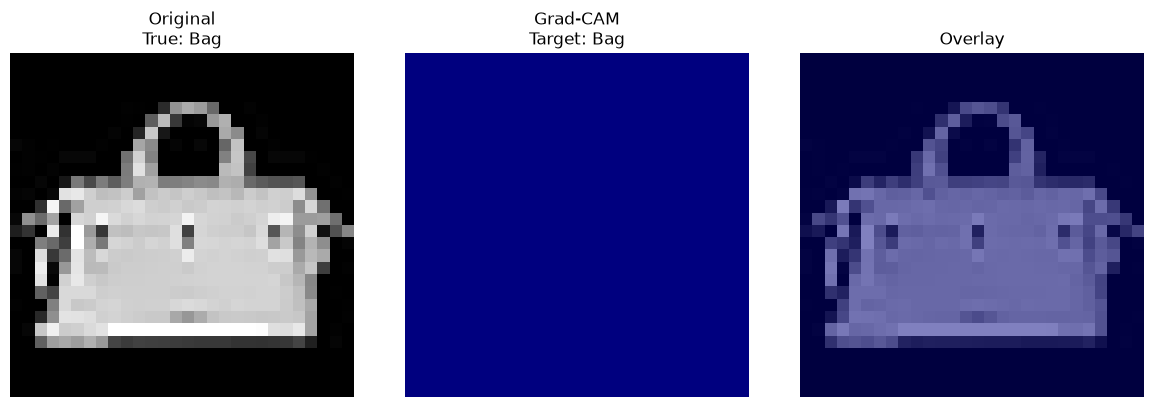

best model


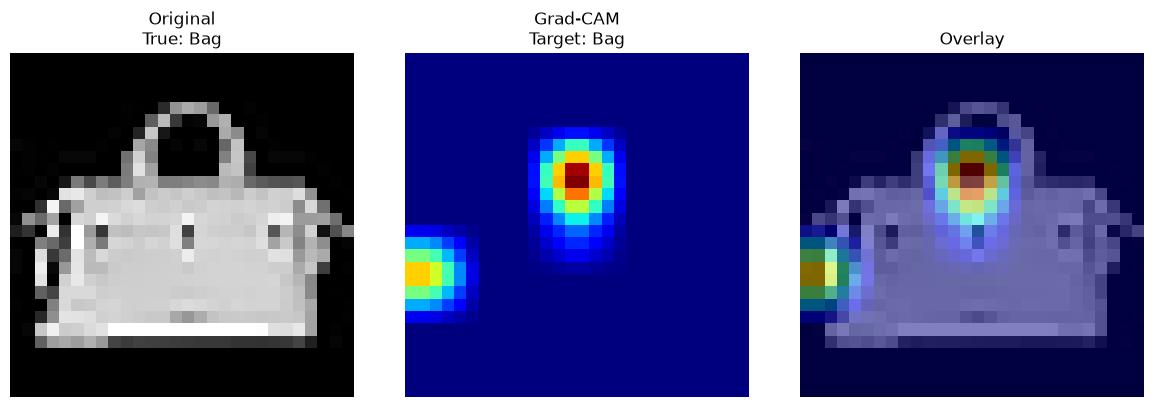

In [47]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


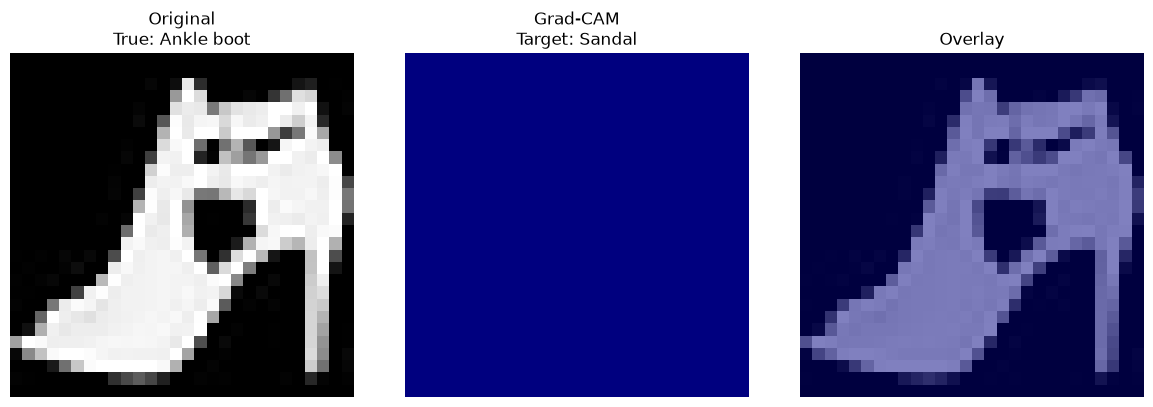

best model


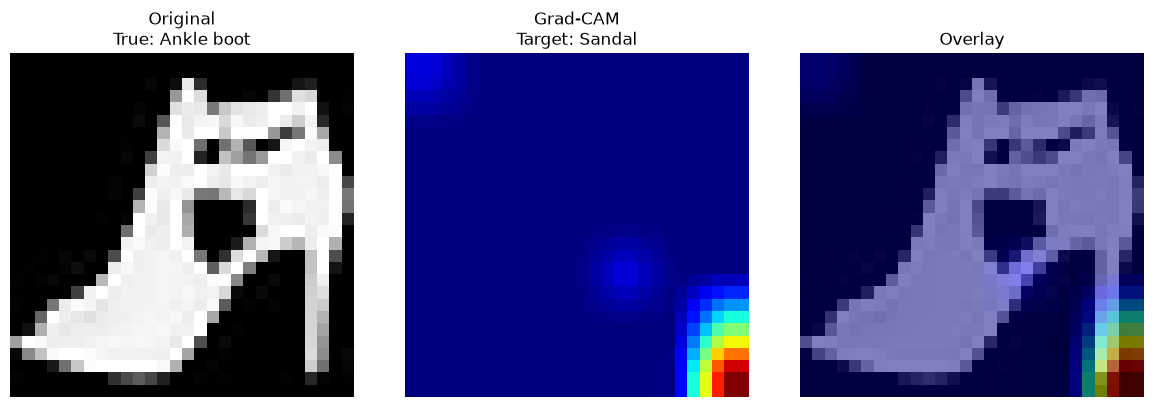

In [48]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


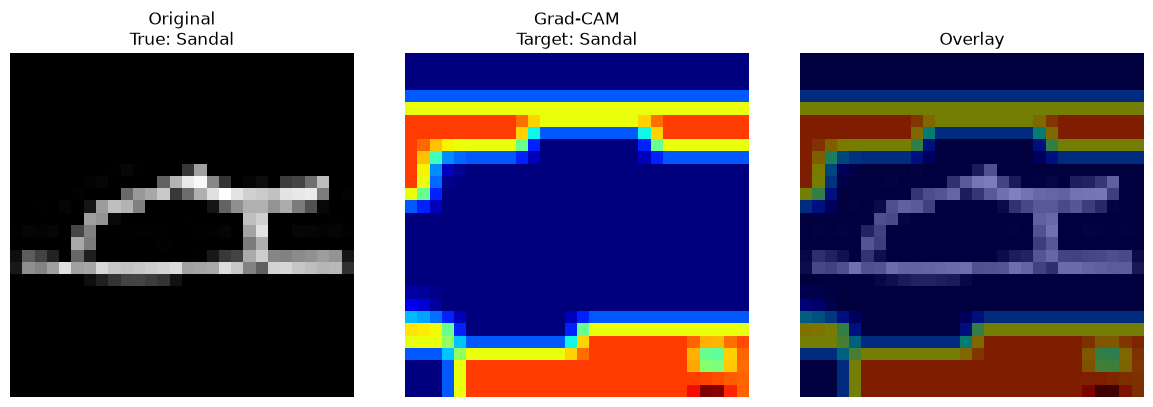

best model


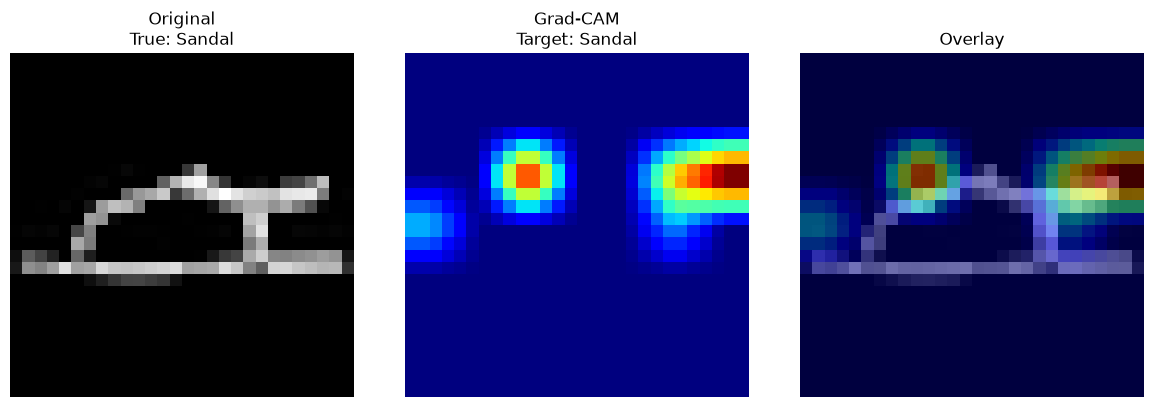

In [49]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


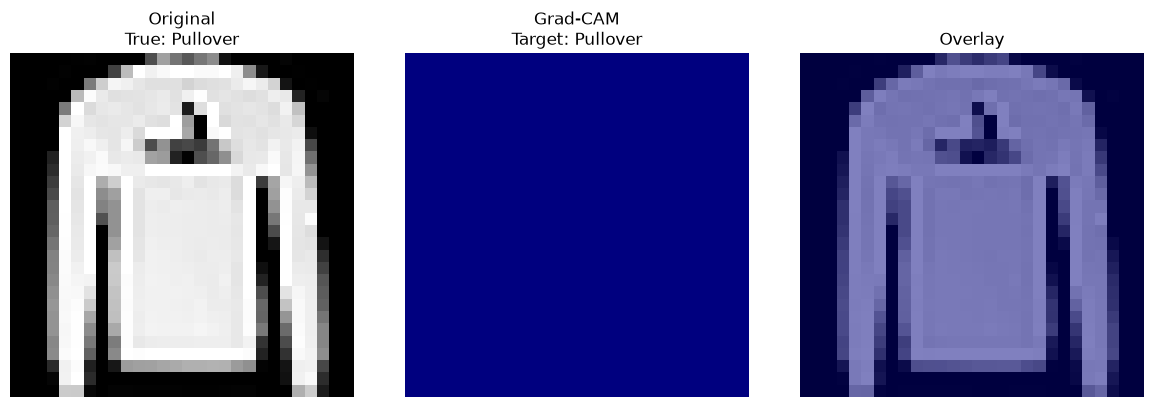

best model


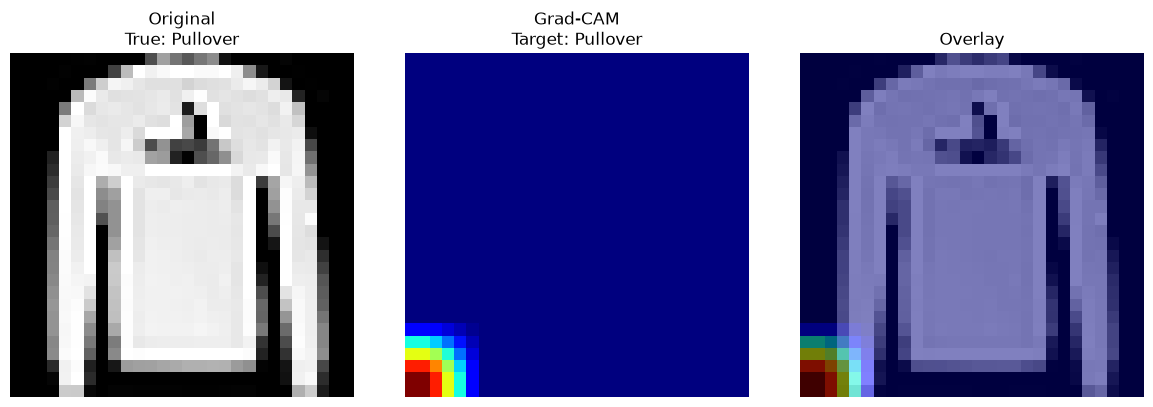

In [50]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


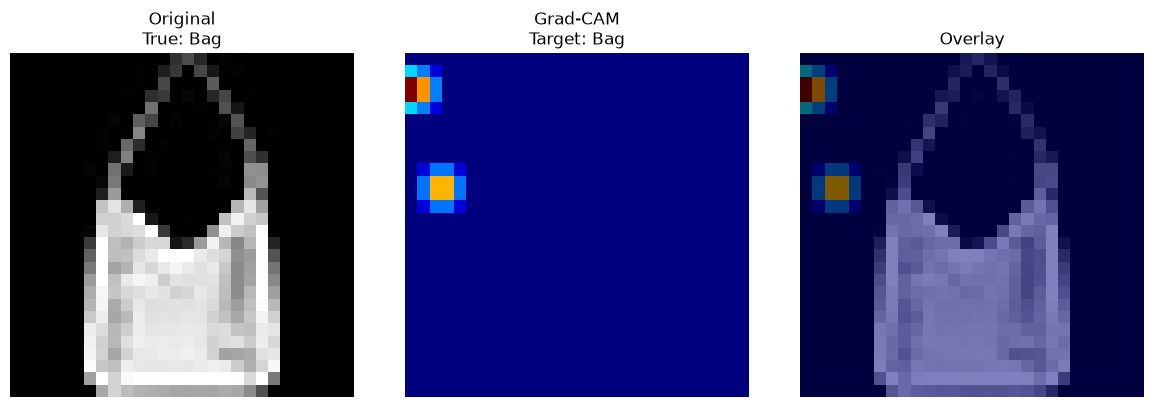

best model


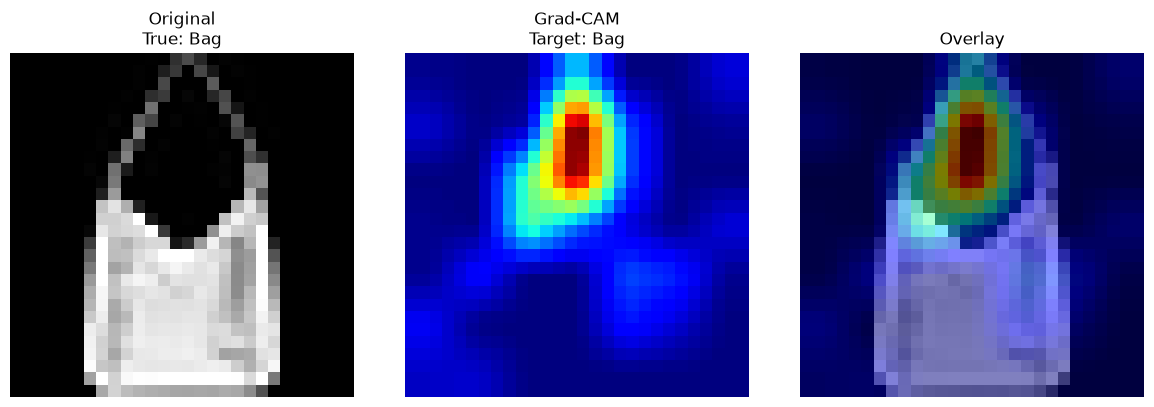

In [51]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


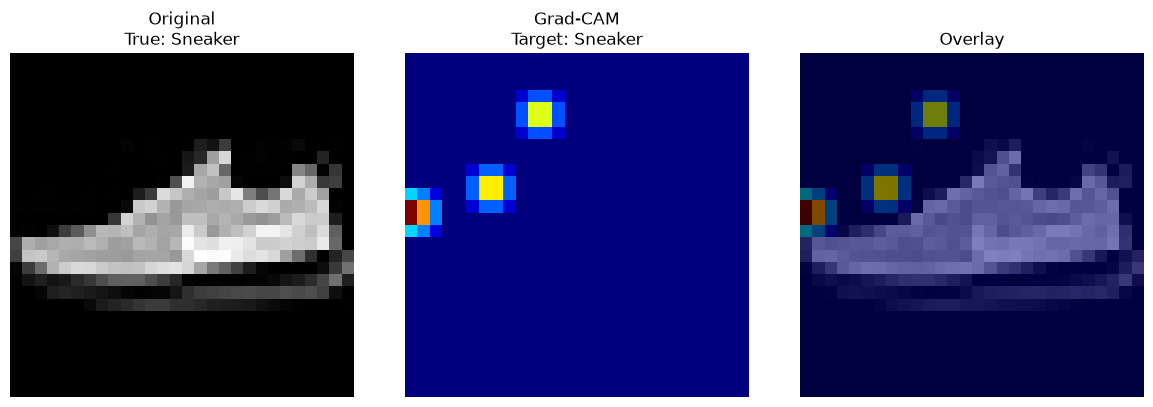

best model


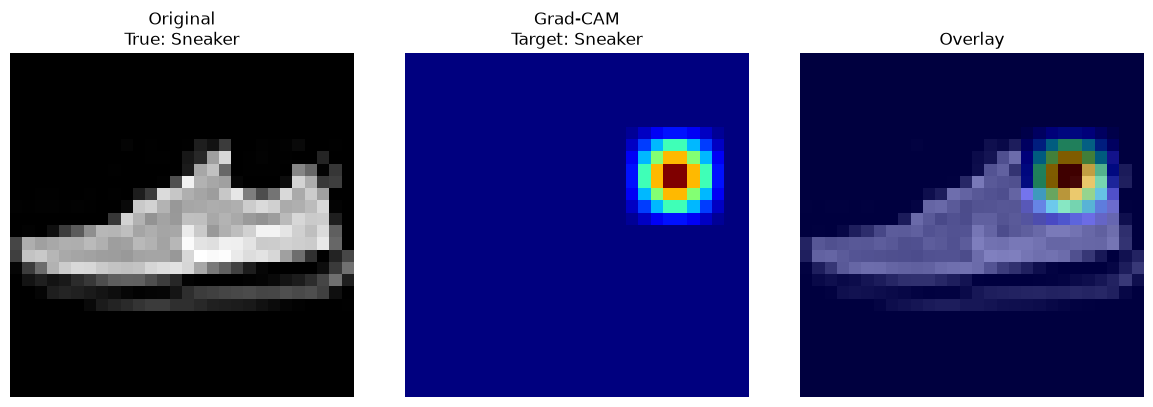

In [52]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


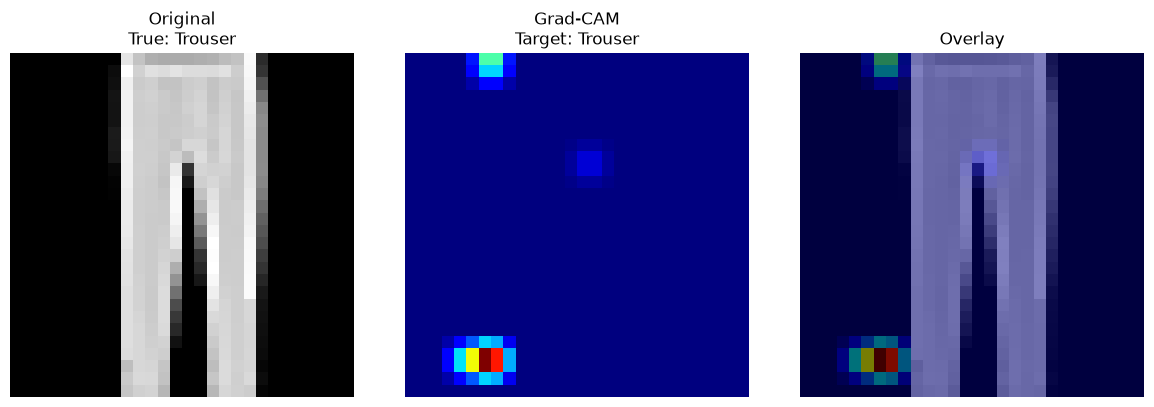

best model


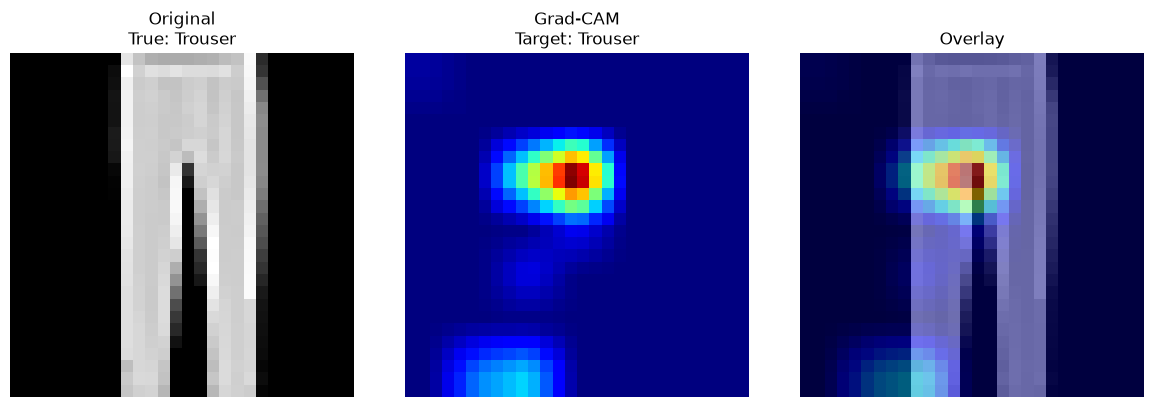

In [53]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


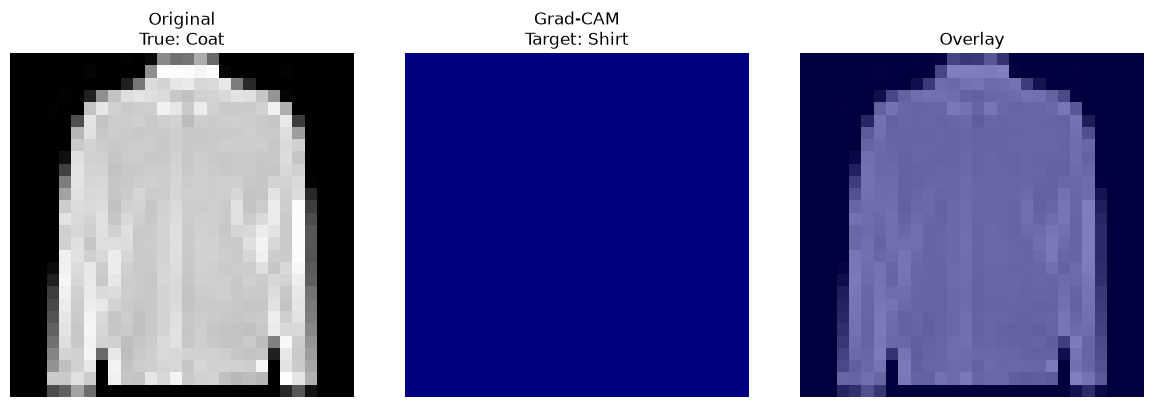

best model


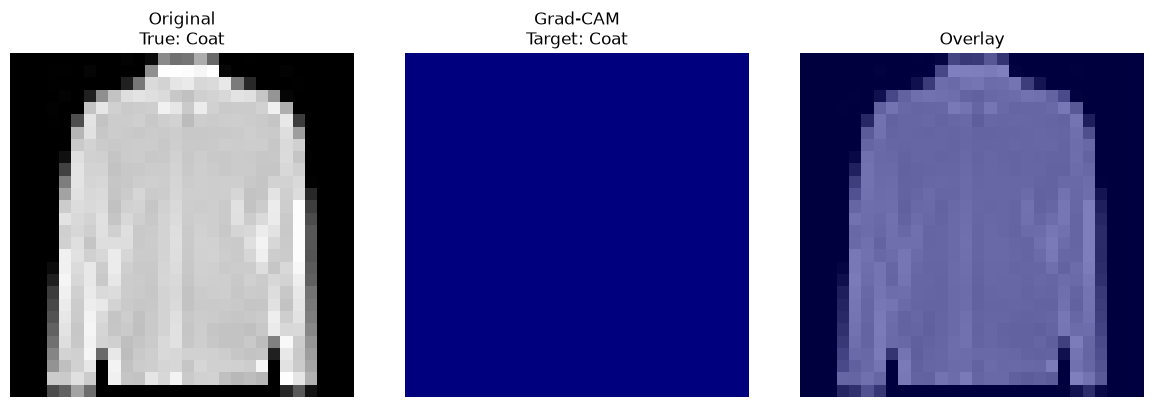

In [54]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


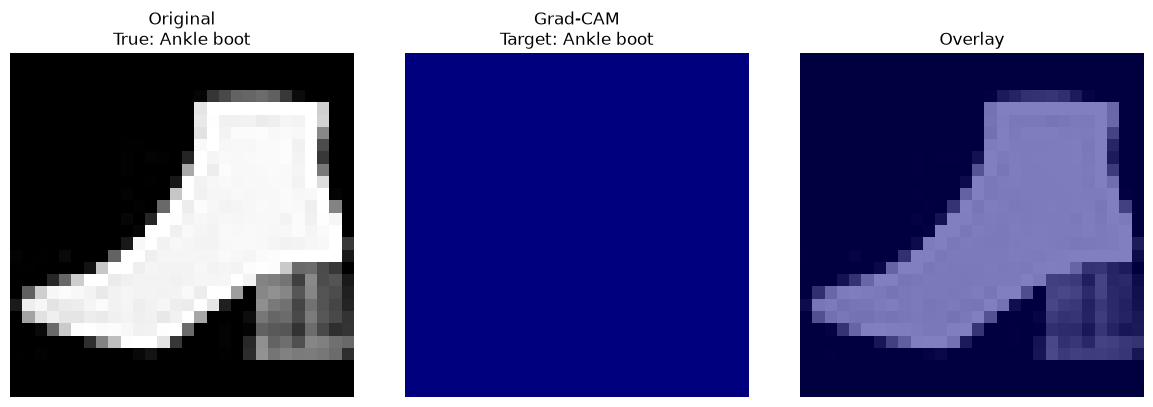

best model


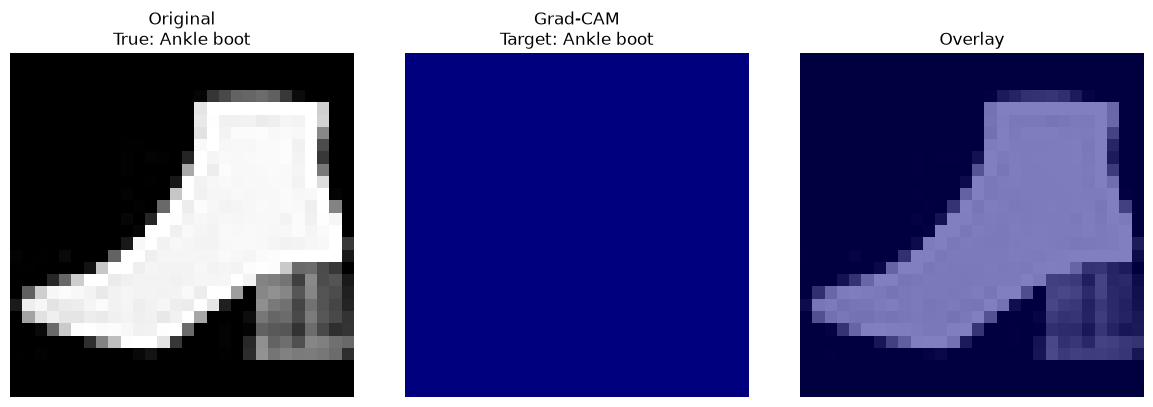

In [55]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


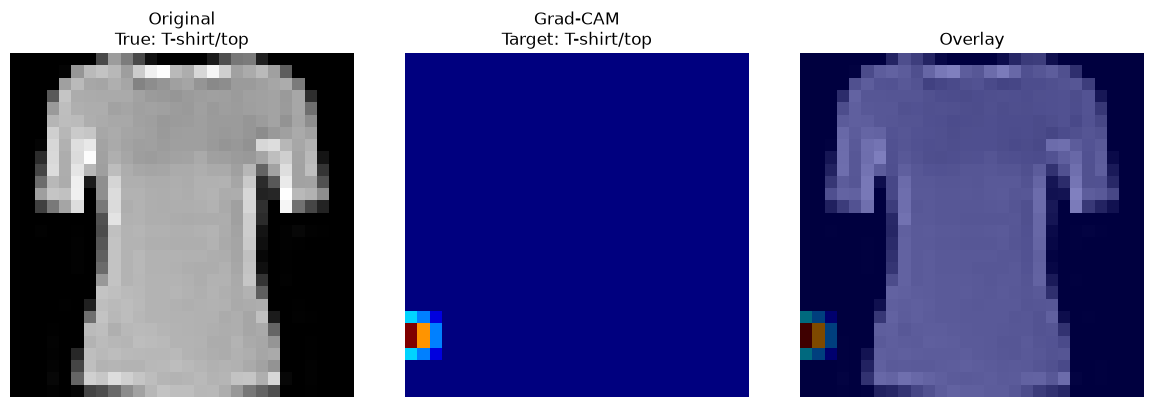

best model


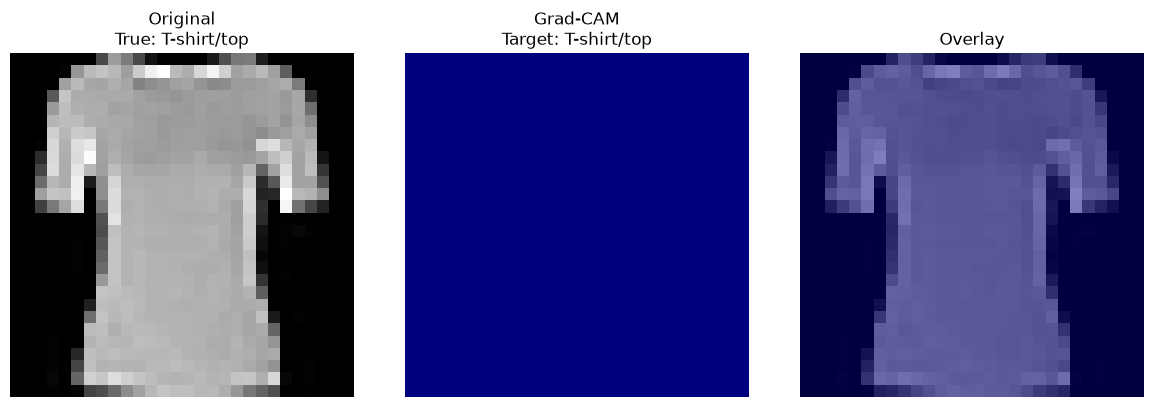

In [56]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


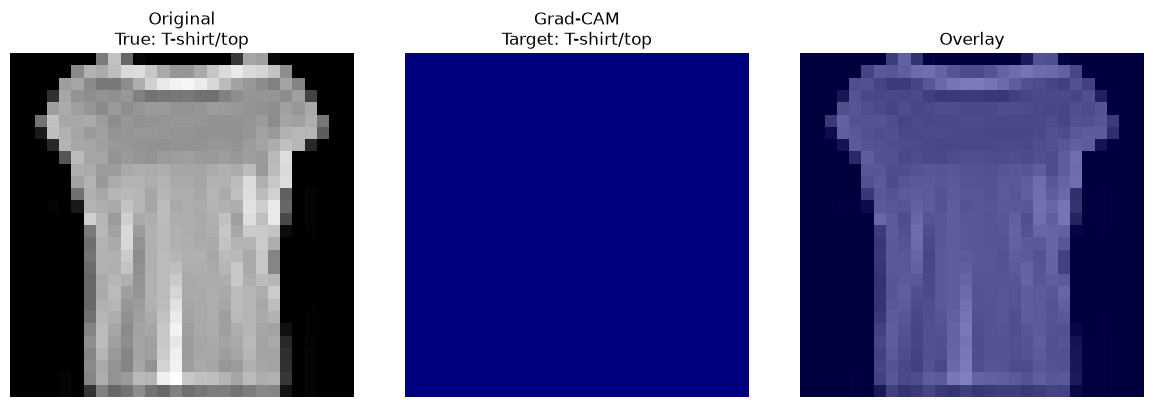

best model


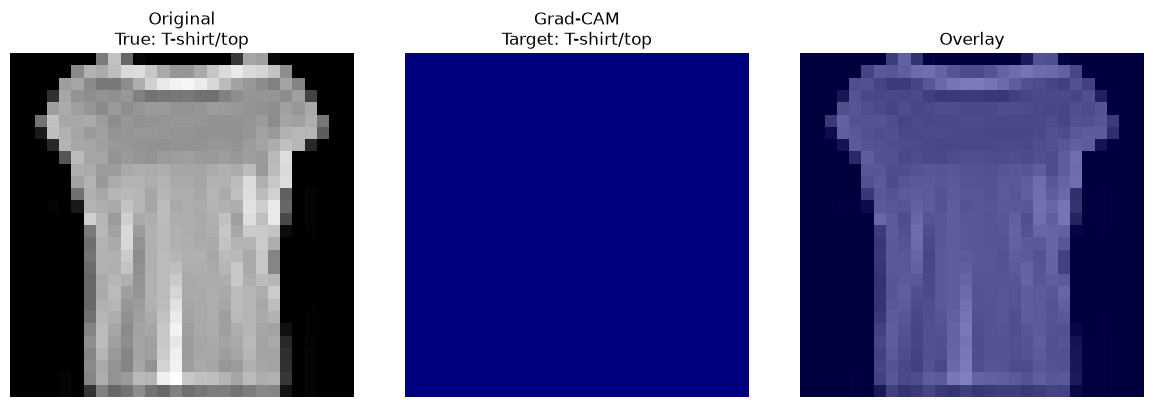

In [57]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


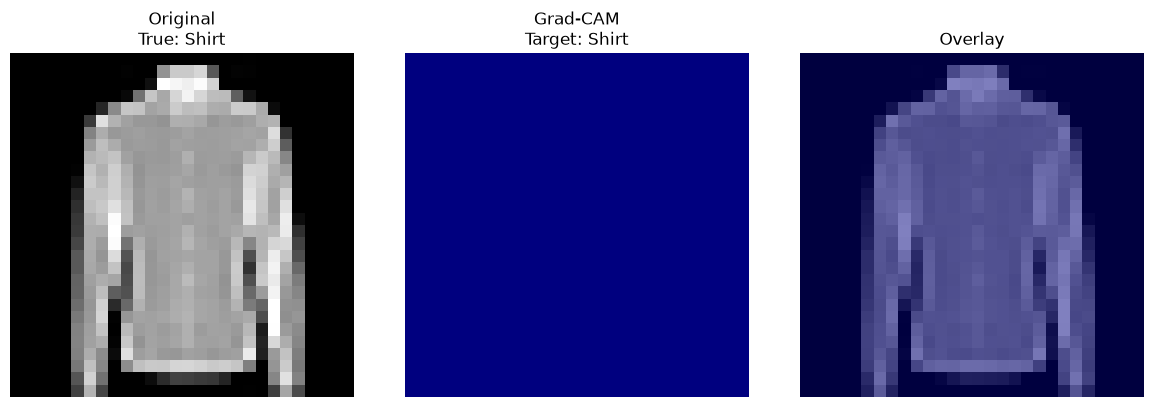

best model


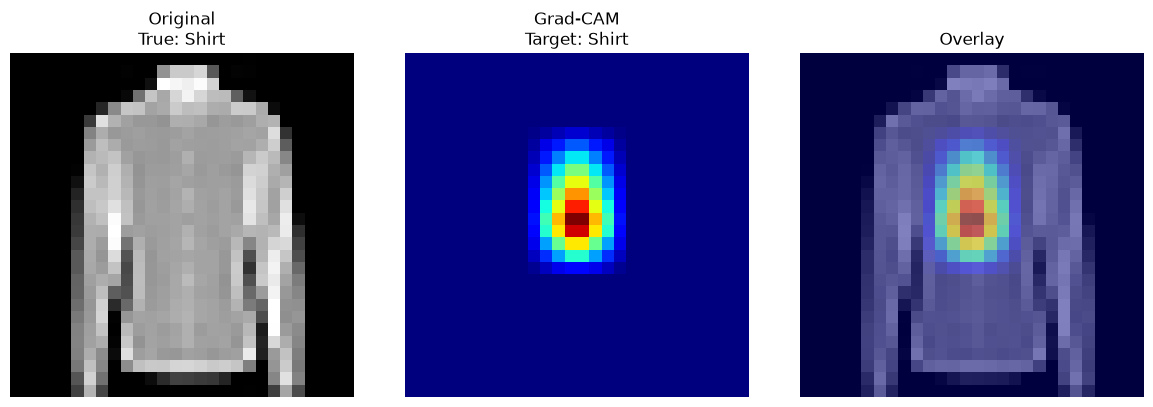

In [58]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


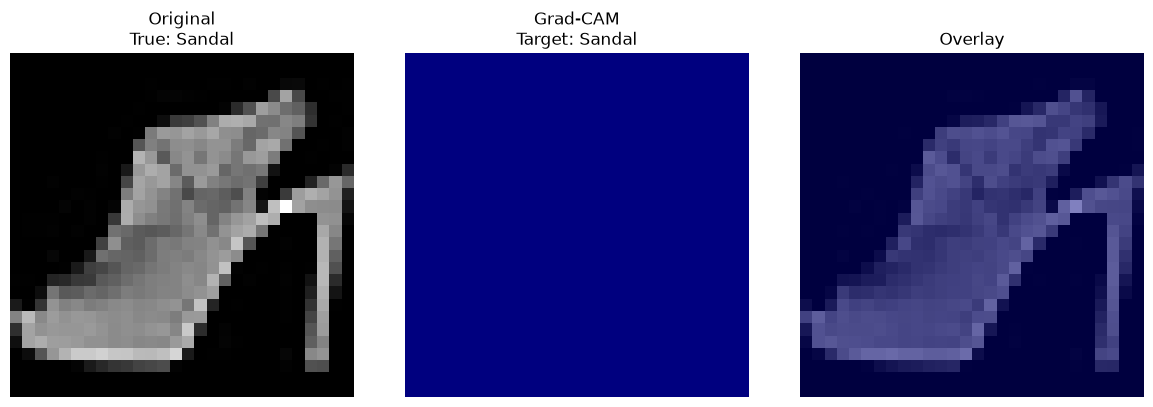

best model


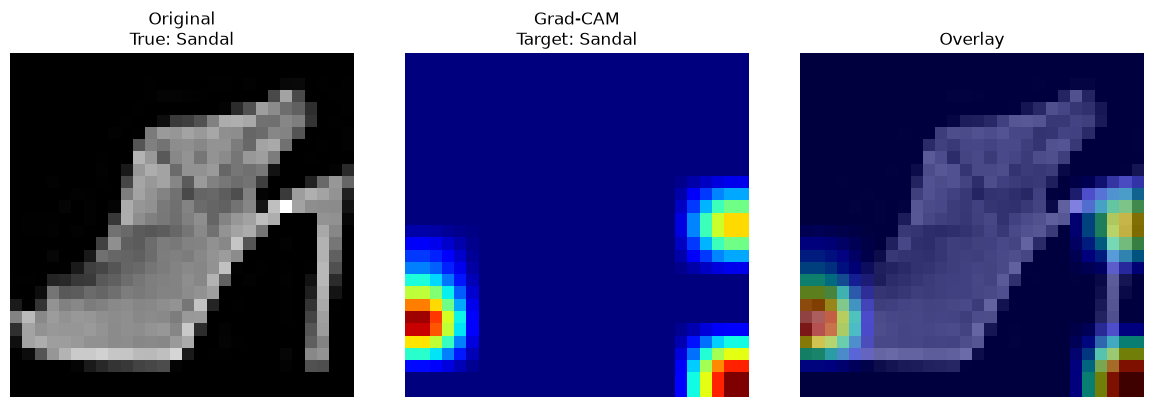

In [59]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


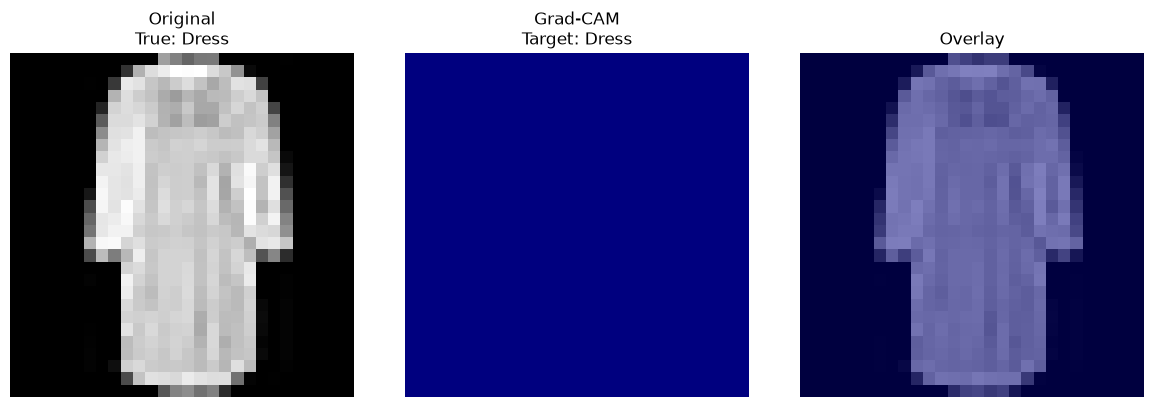

best model


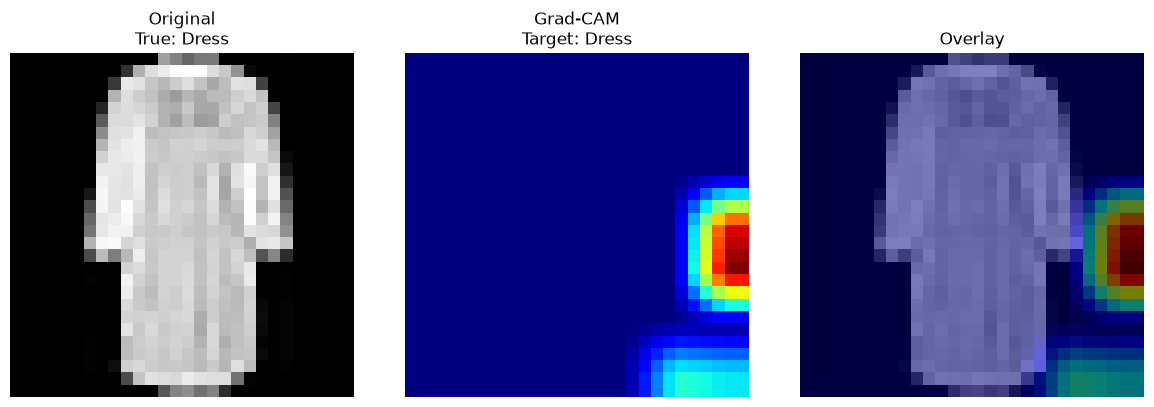

In [60]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


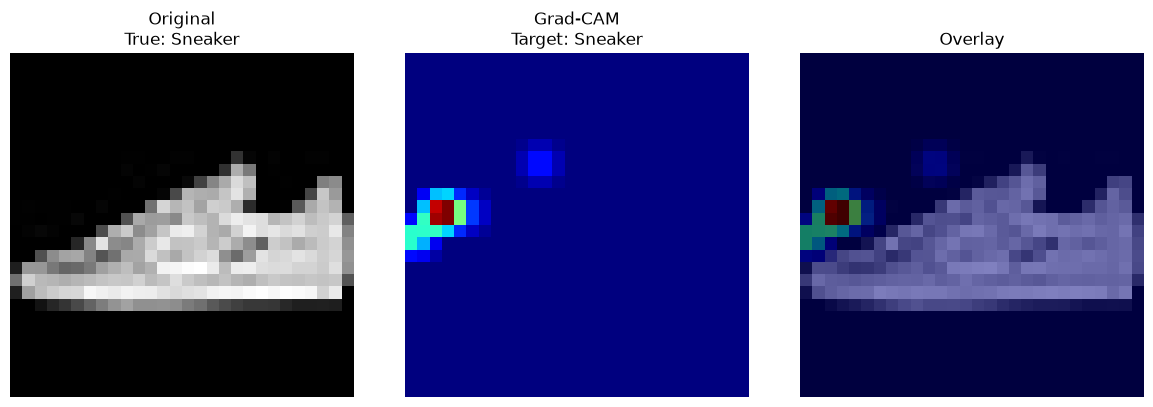

best model


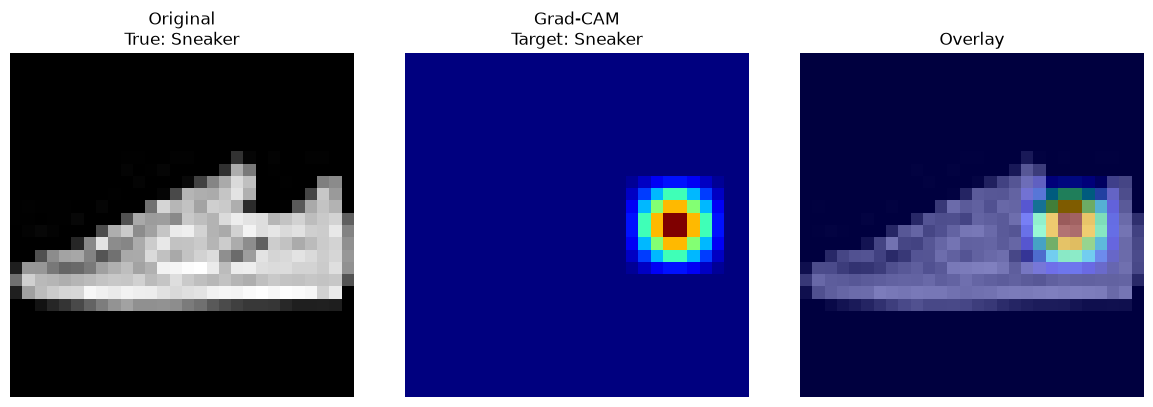

In [61]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


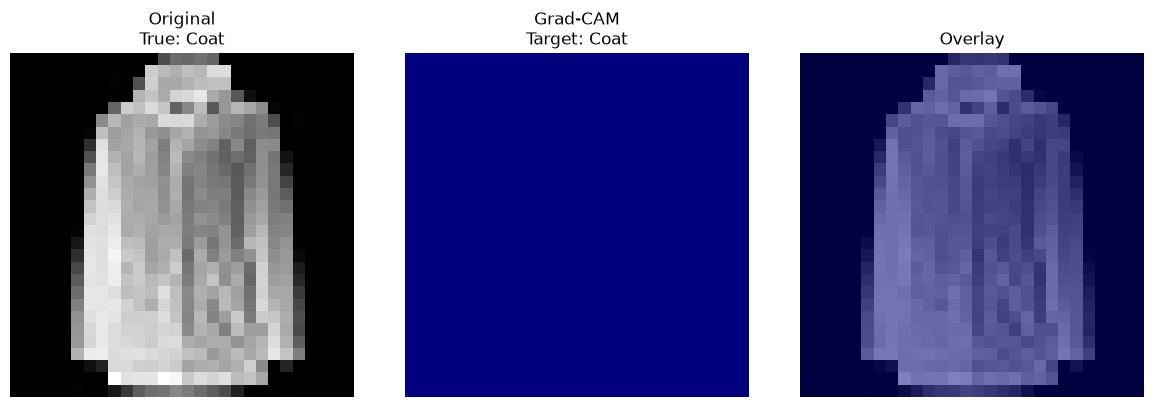

best model


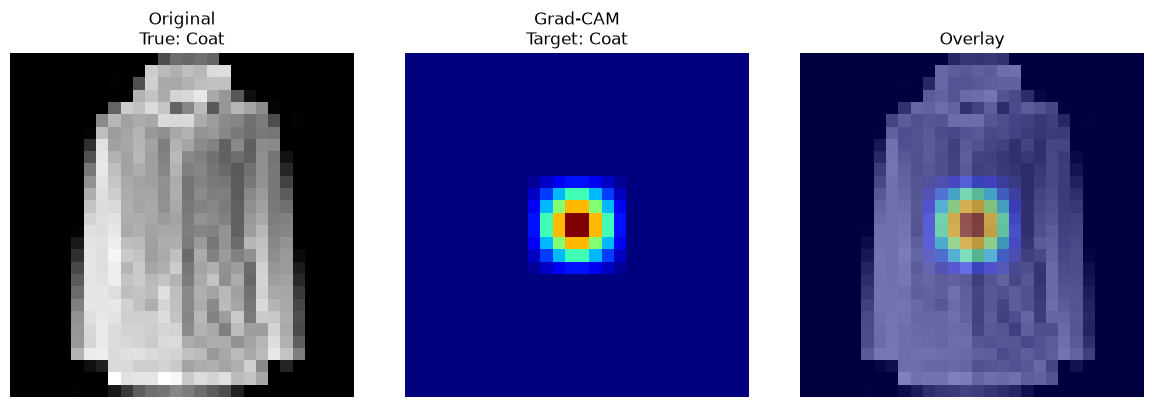

In [62]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


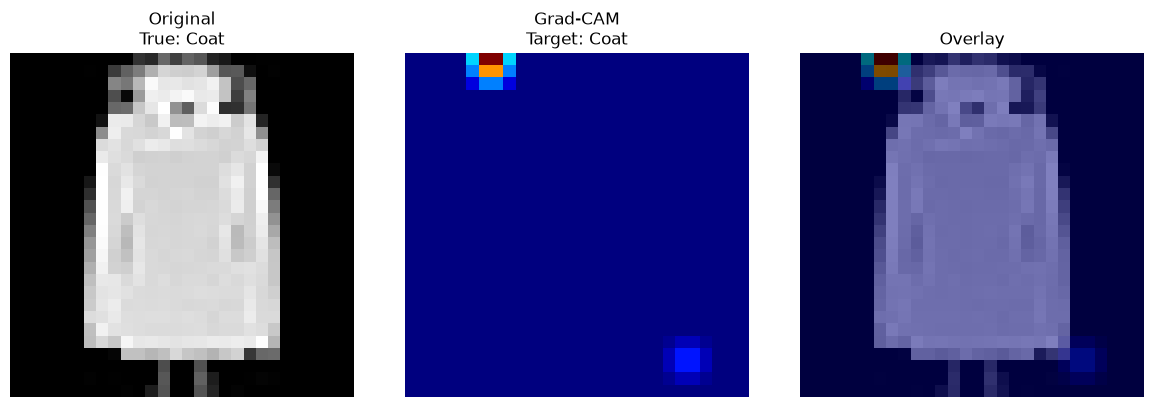

best model


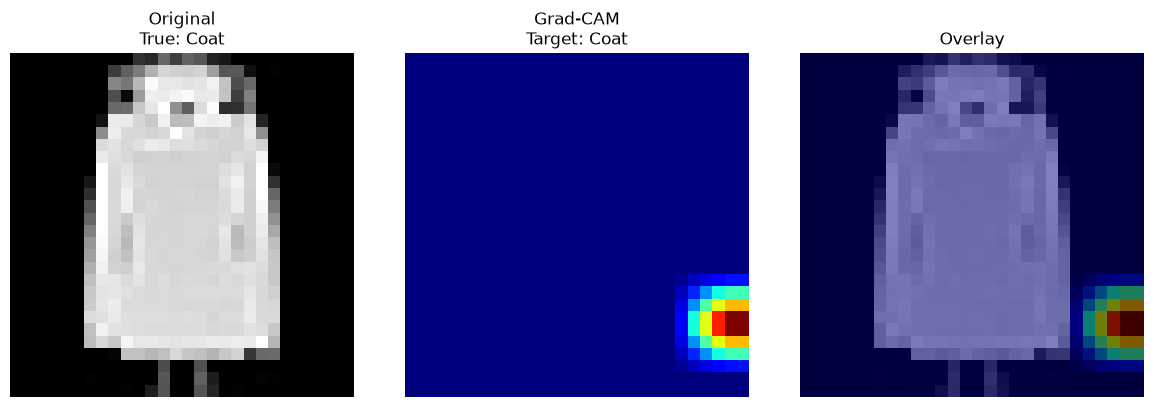

In [63]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


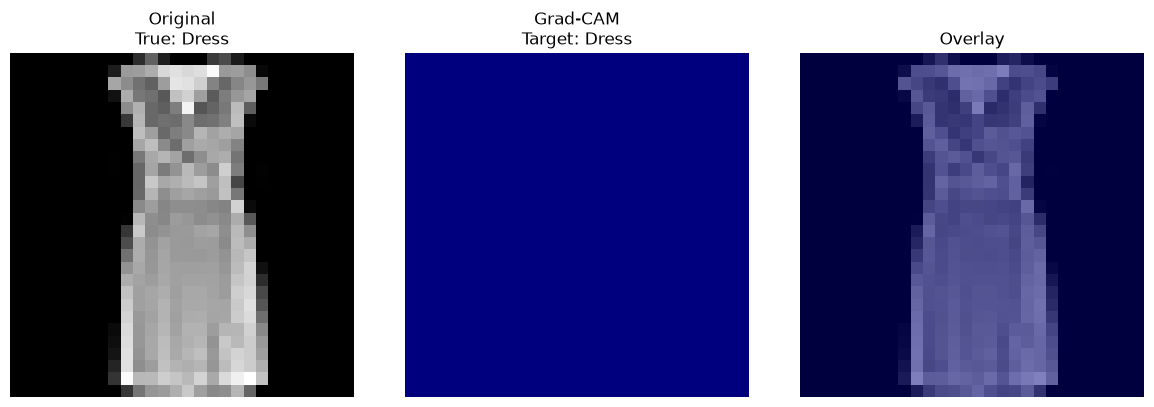

best model


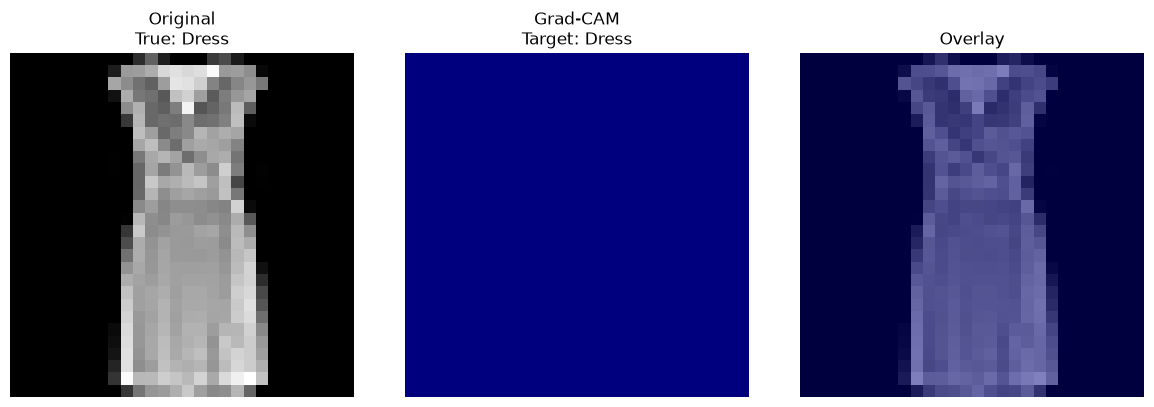

In [64]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


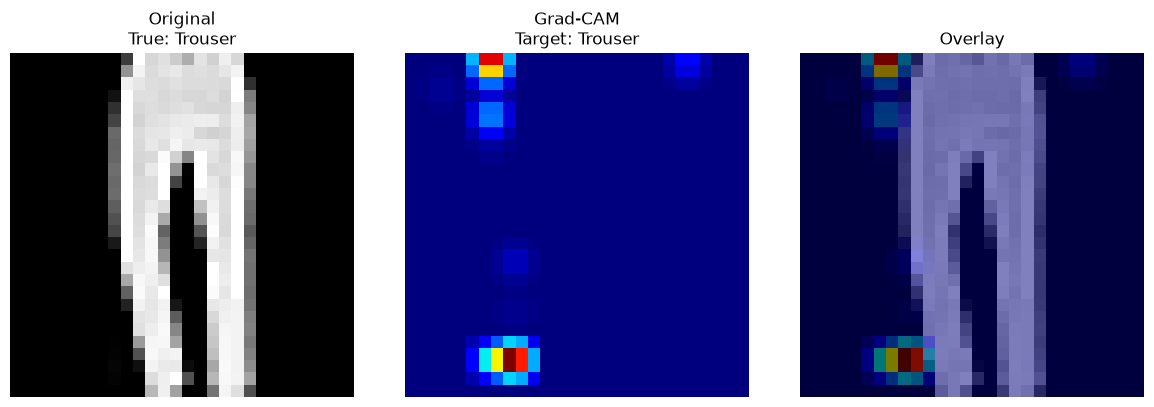

best model


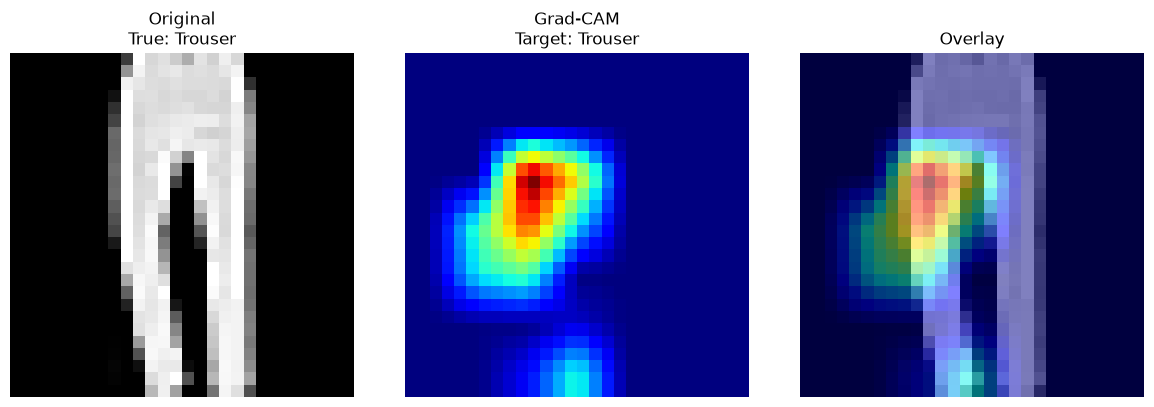

In [65]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


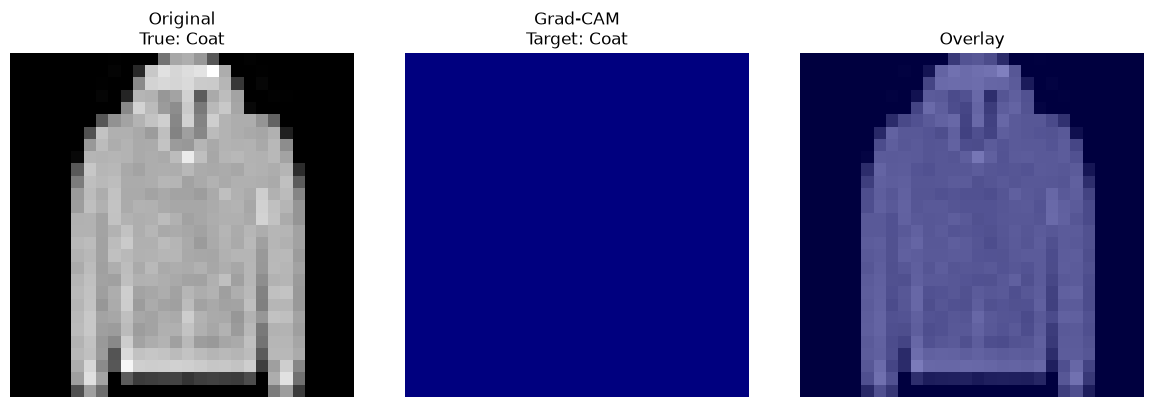

best model


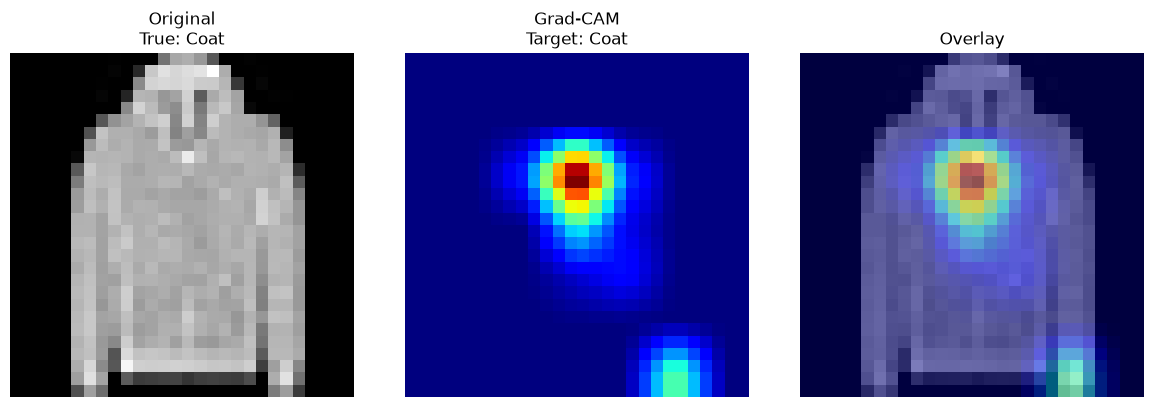

In [66]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


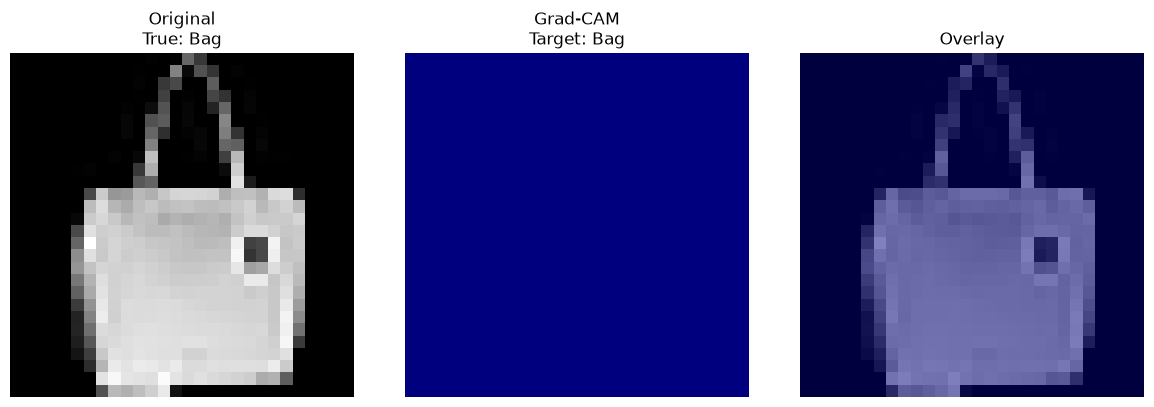

best model


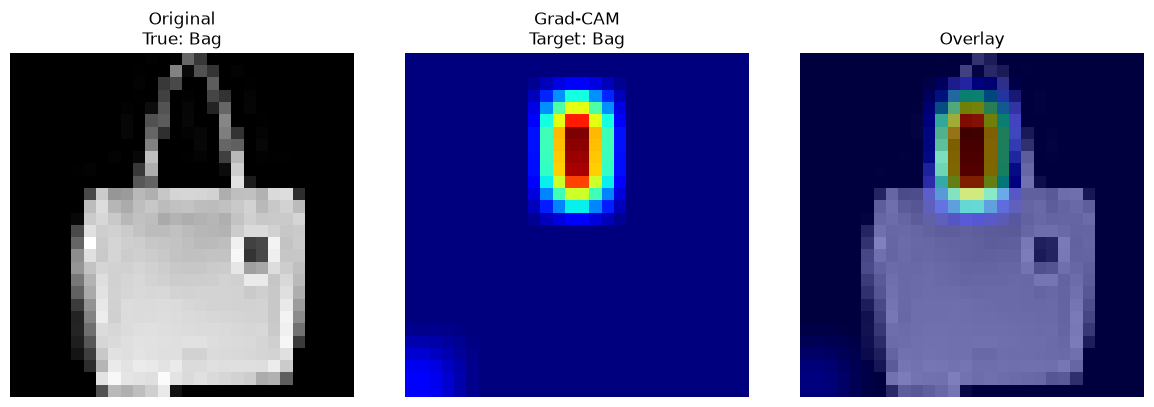

In [67]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


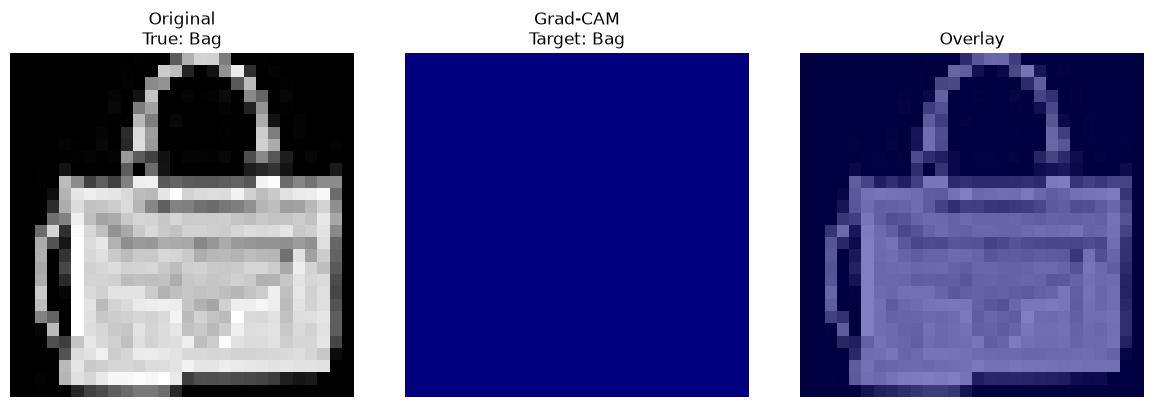

best model


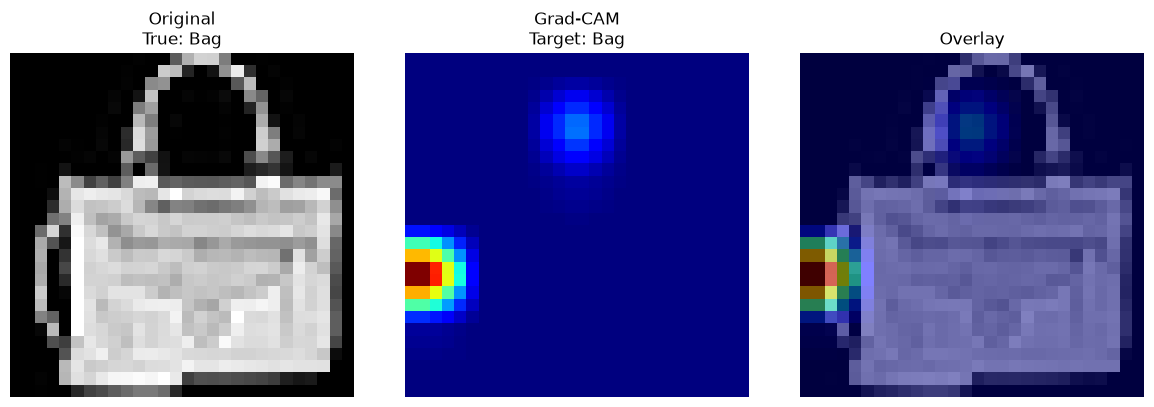

In [68]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


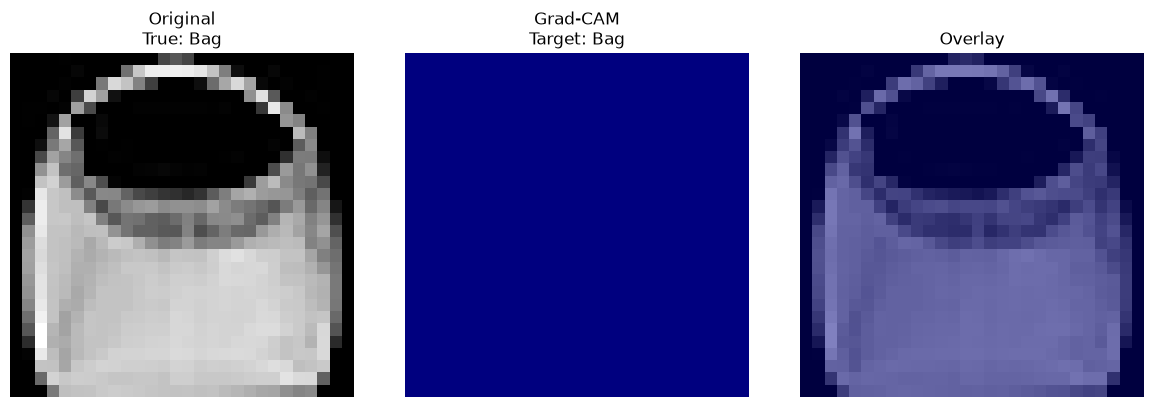

best model


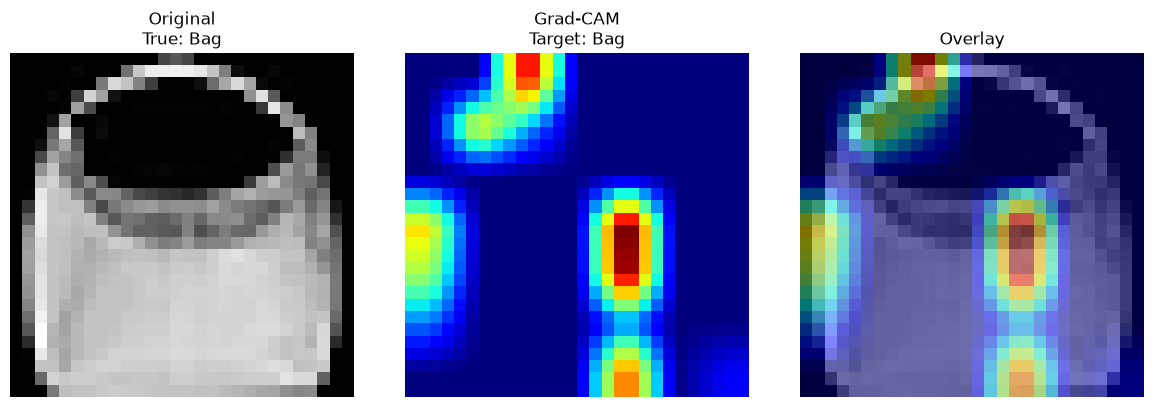

In [69]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


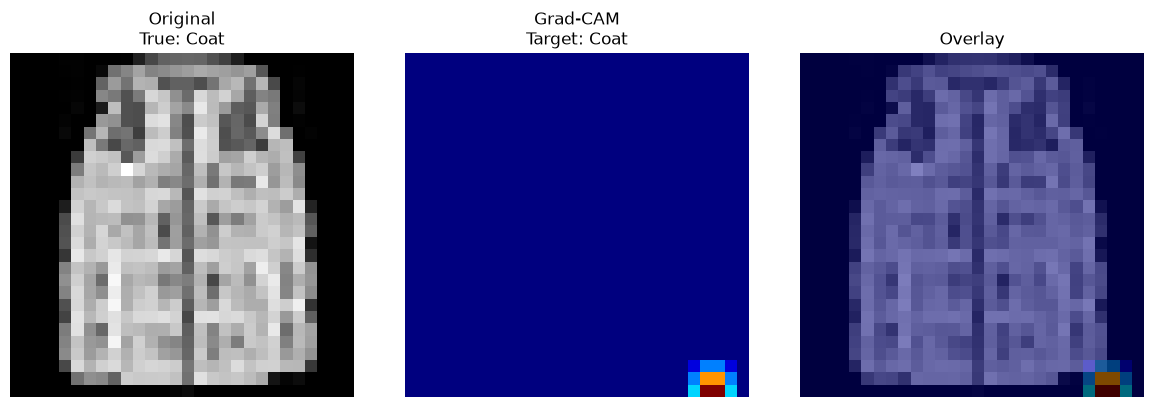

best model


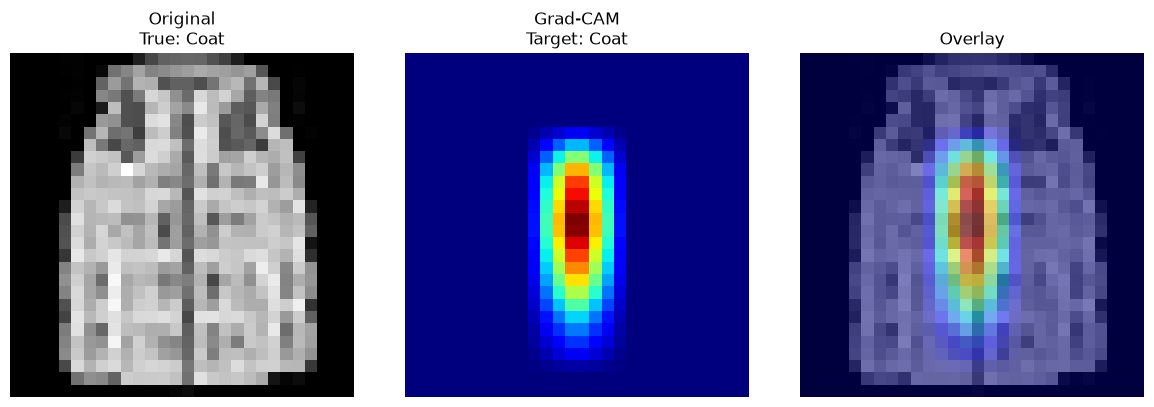

In [70]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


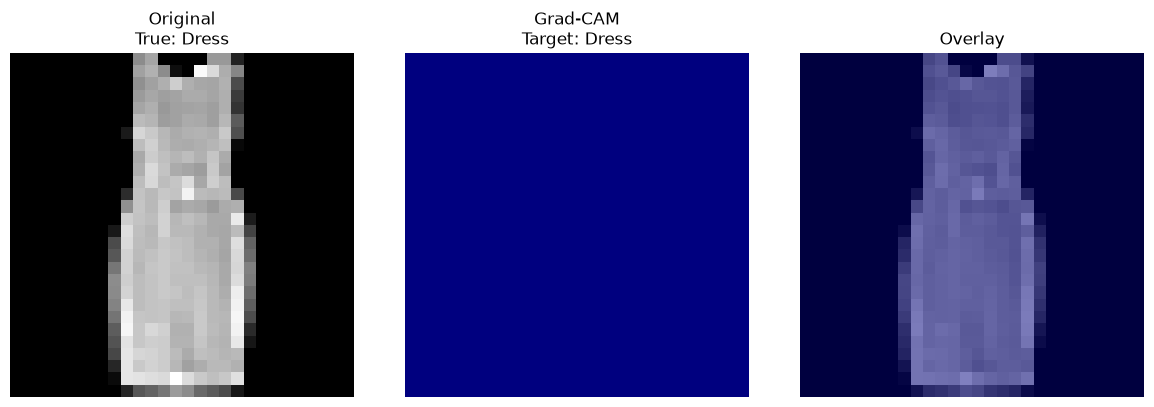

best model


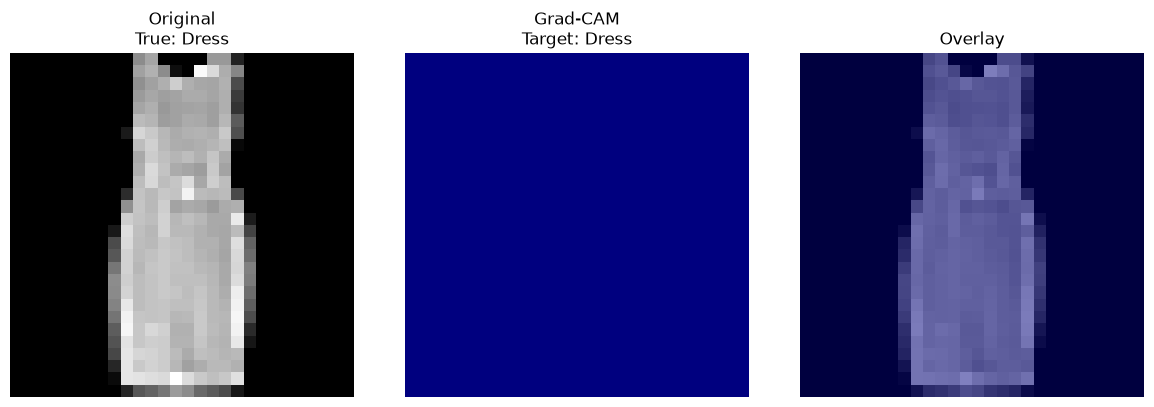

In [71]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


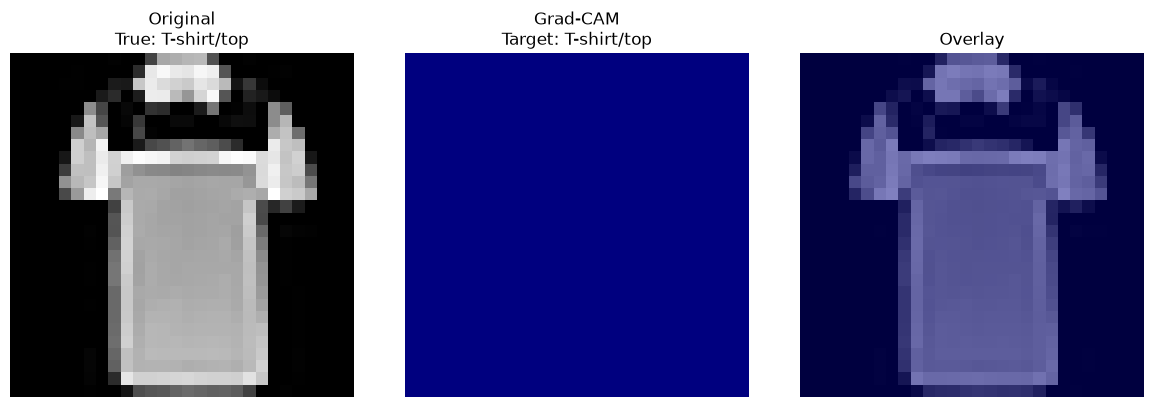

best model


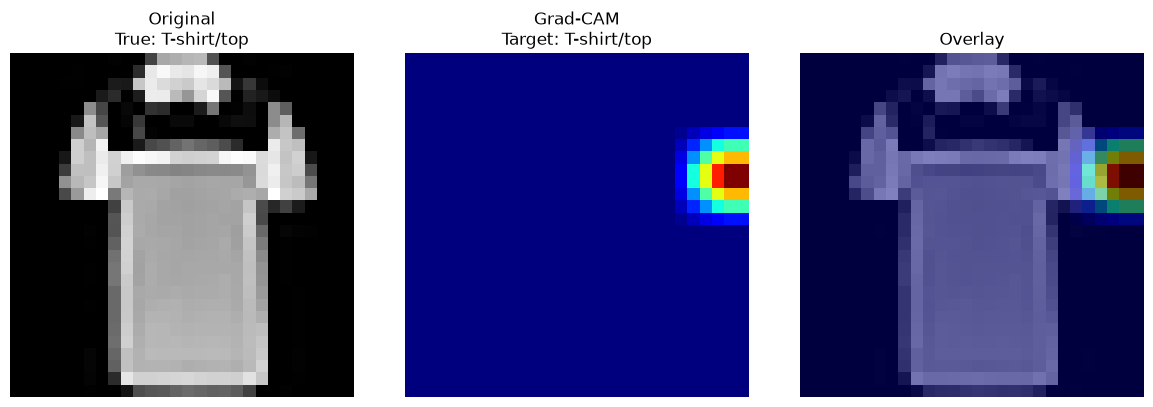

In [72]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


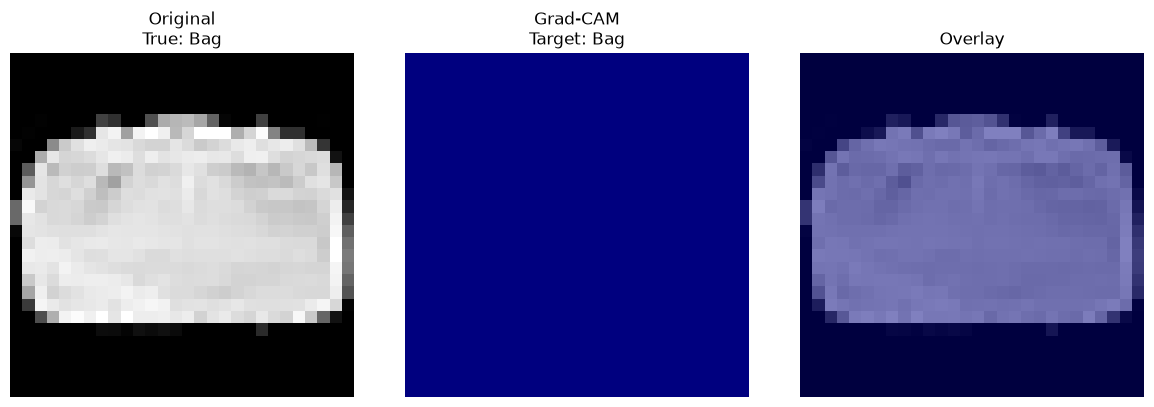

best model


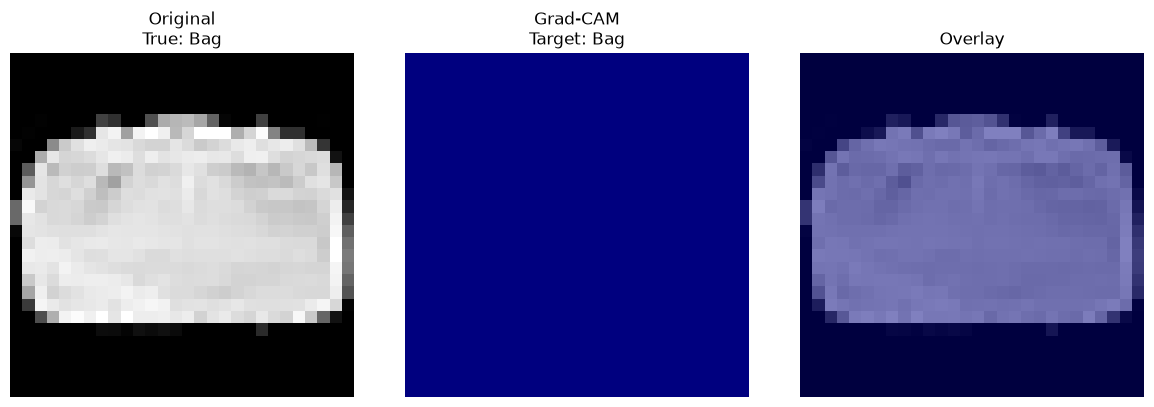

In [73]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


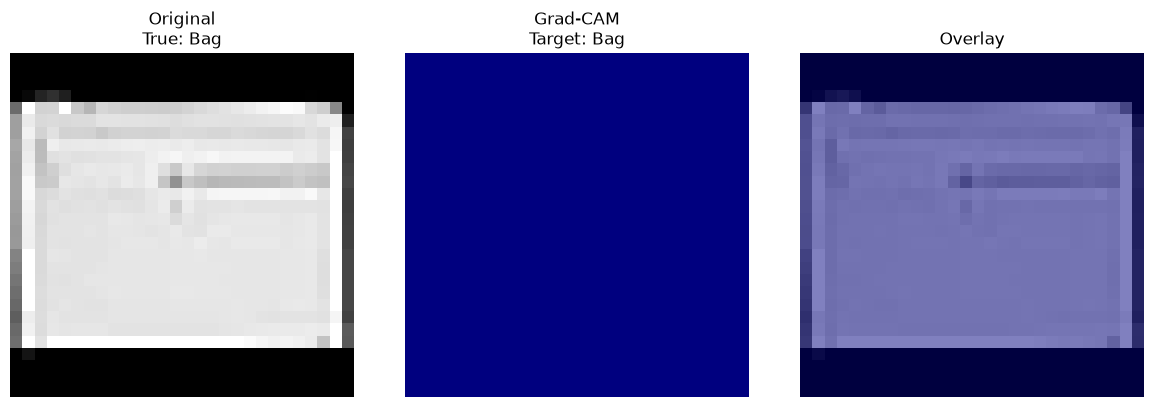

best model


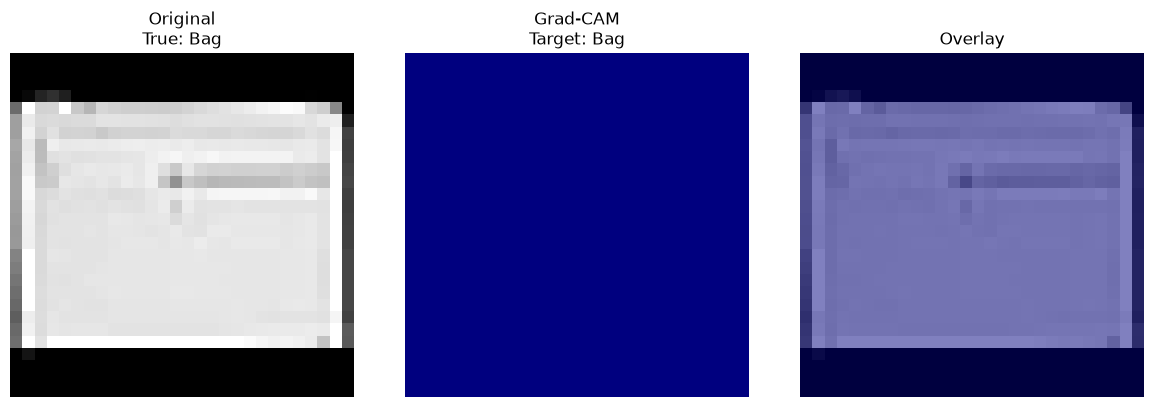

In [74]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


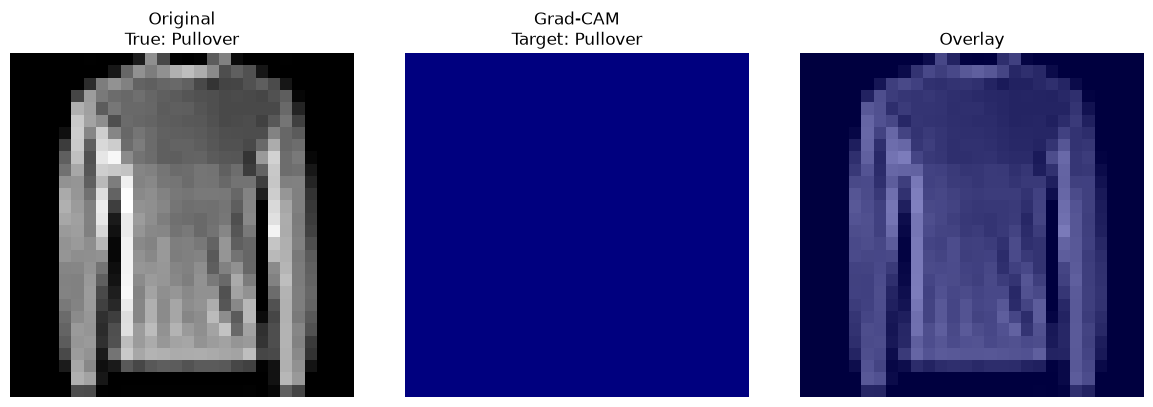

best model


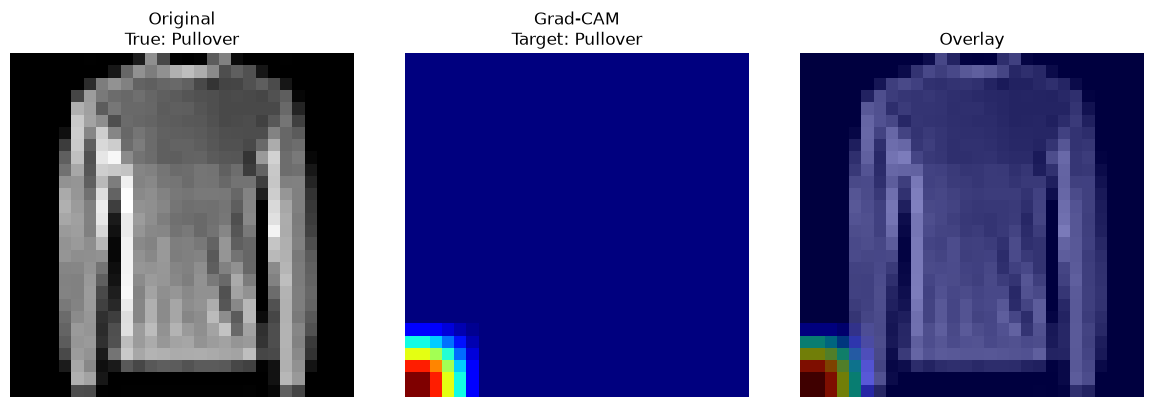

In [75]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


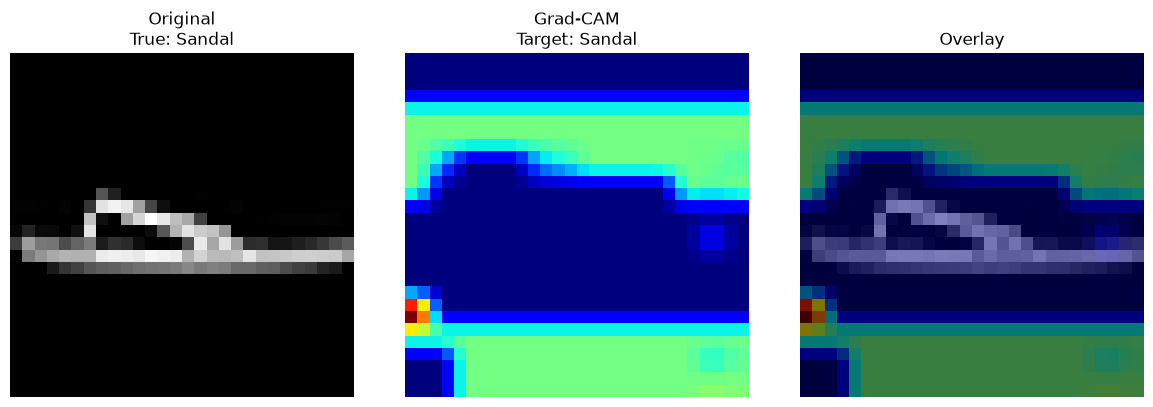

best model


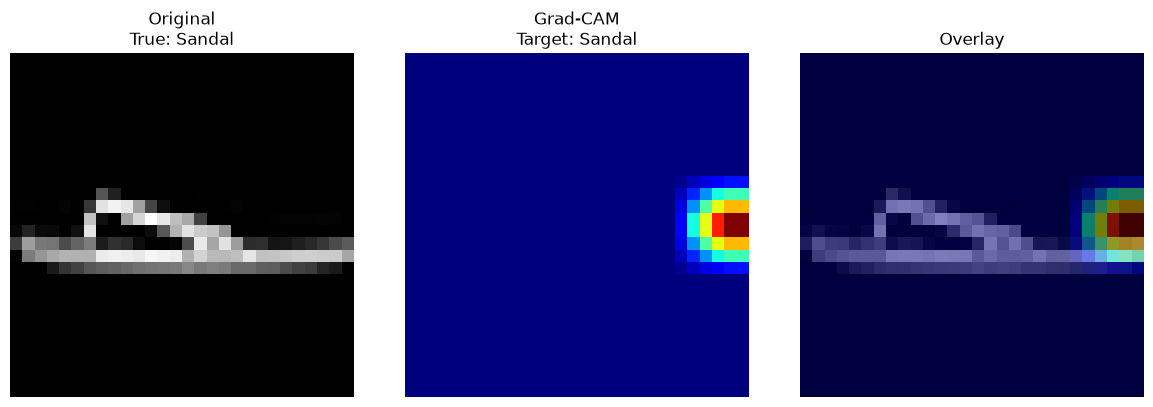

In [76]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


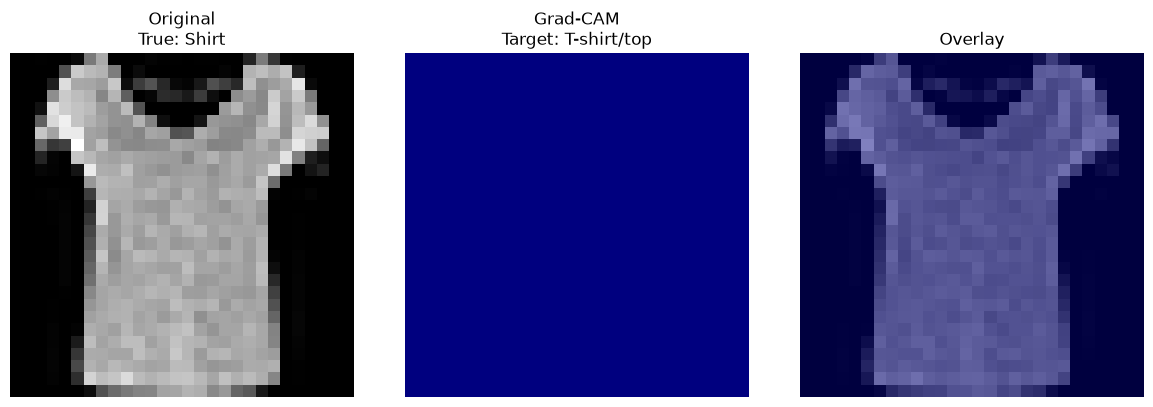

best model


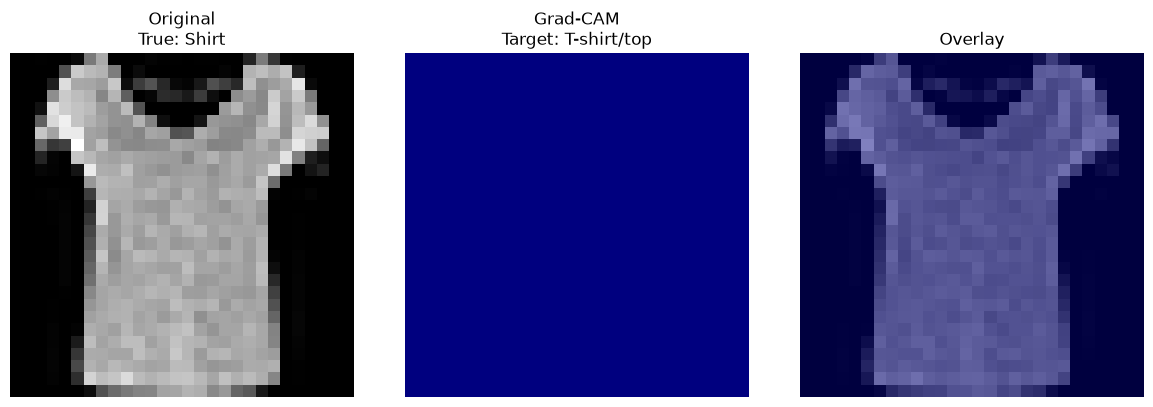

In [77]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


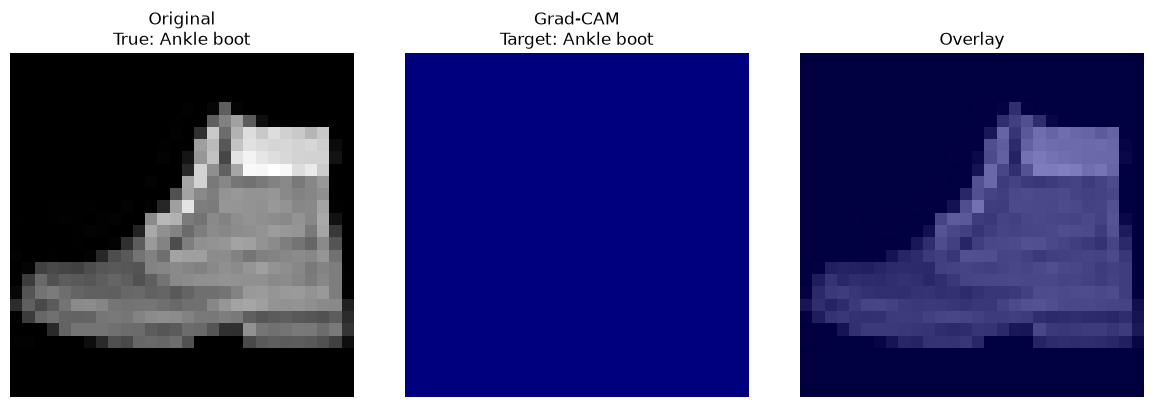

best model


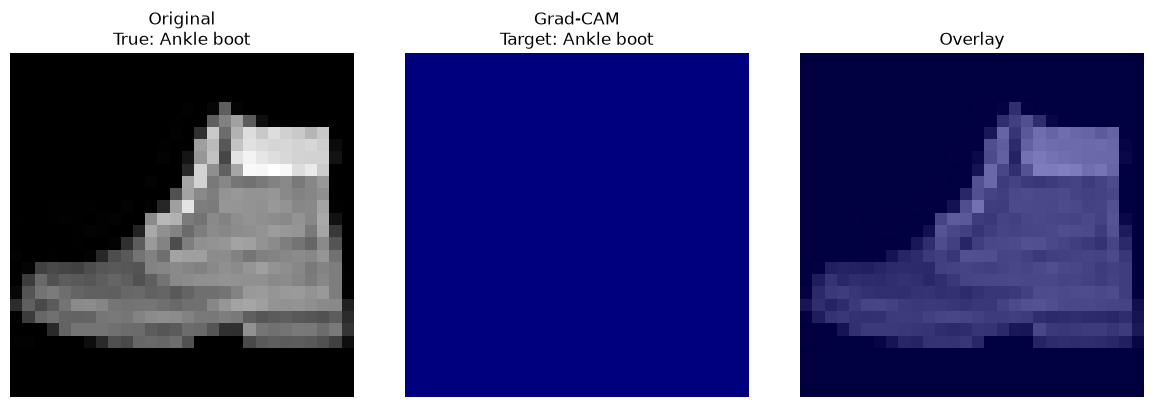

In [78]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


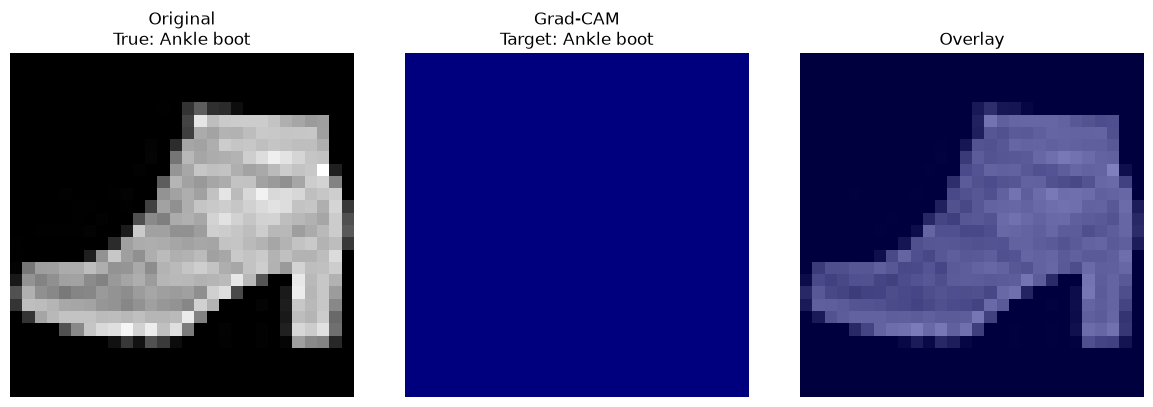

best model


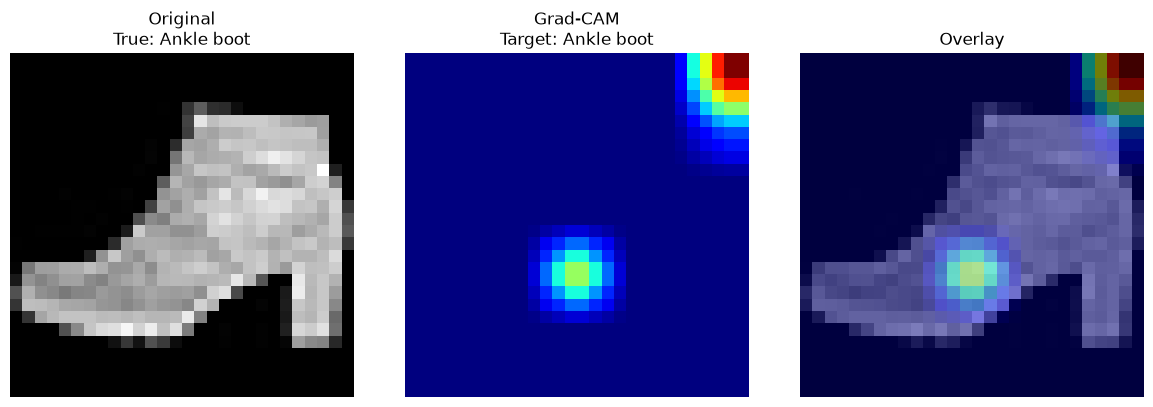

In [79]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


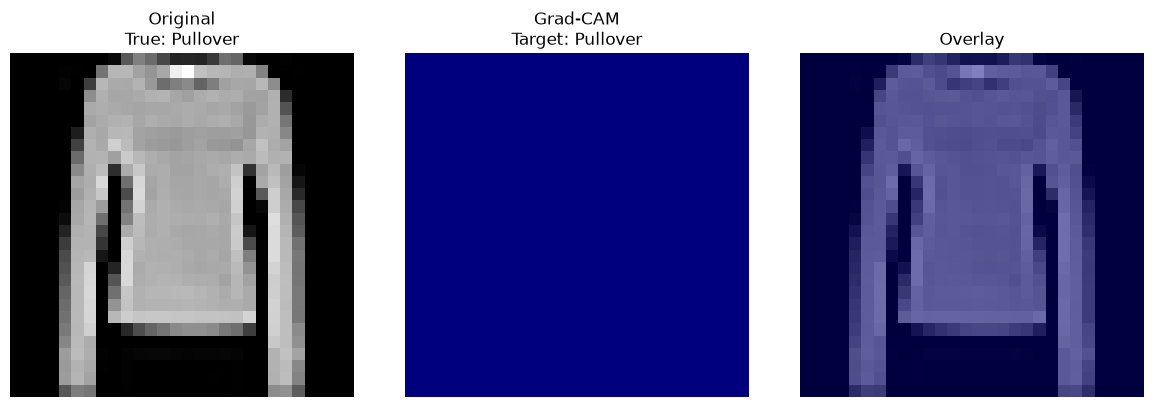

best model


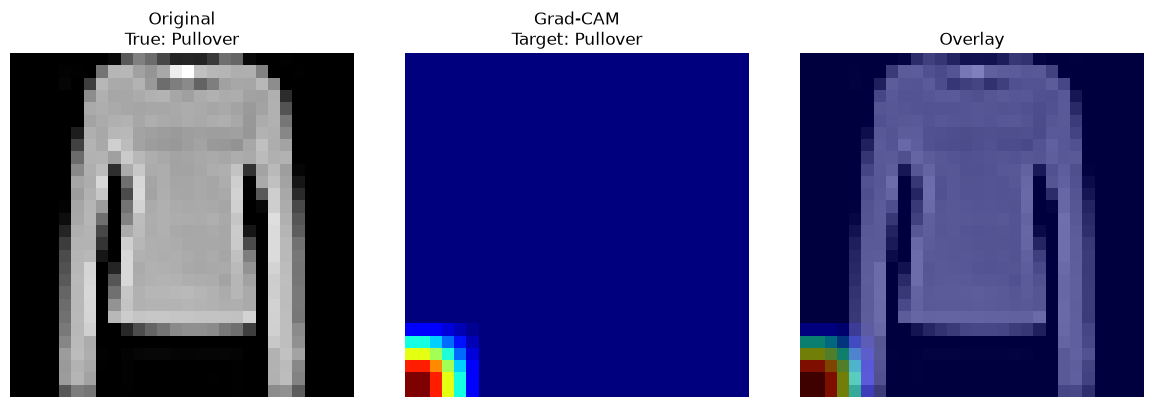

In [80]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


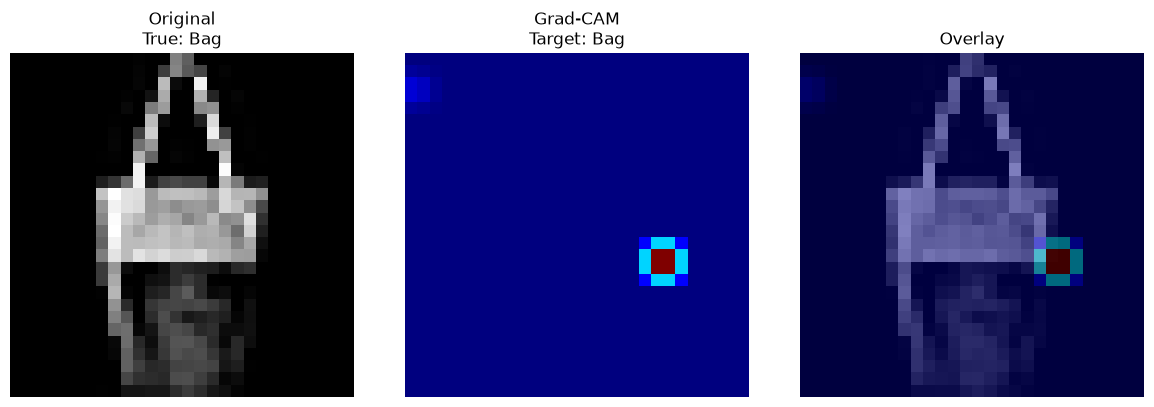

best model


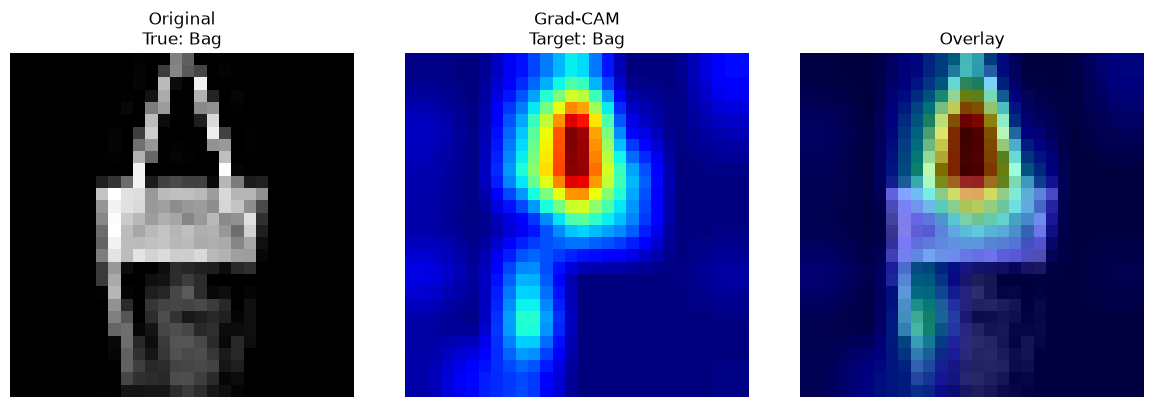

In [81]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


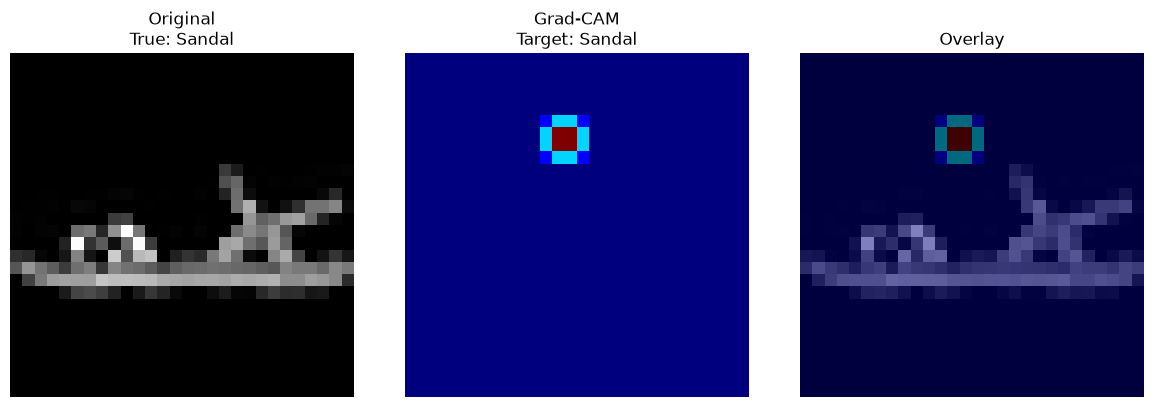

best model


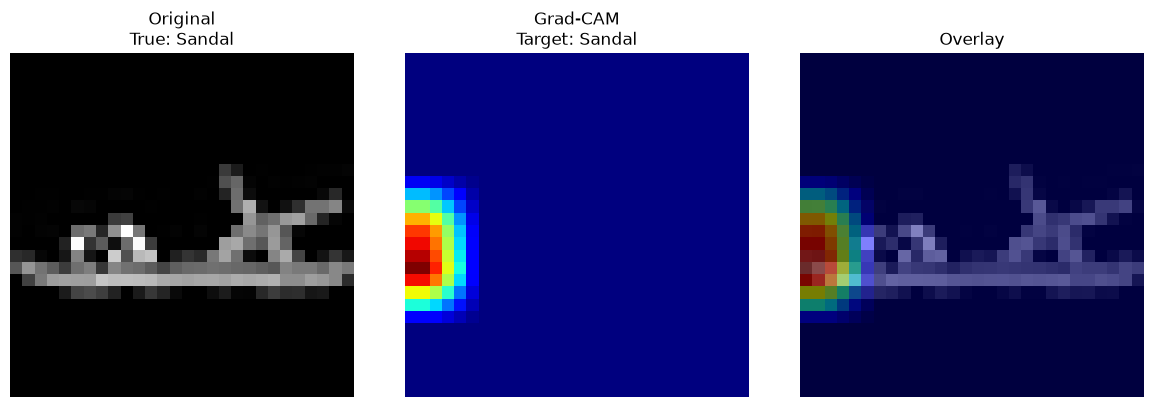

In [82]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

1k model


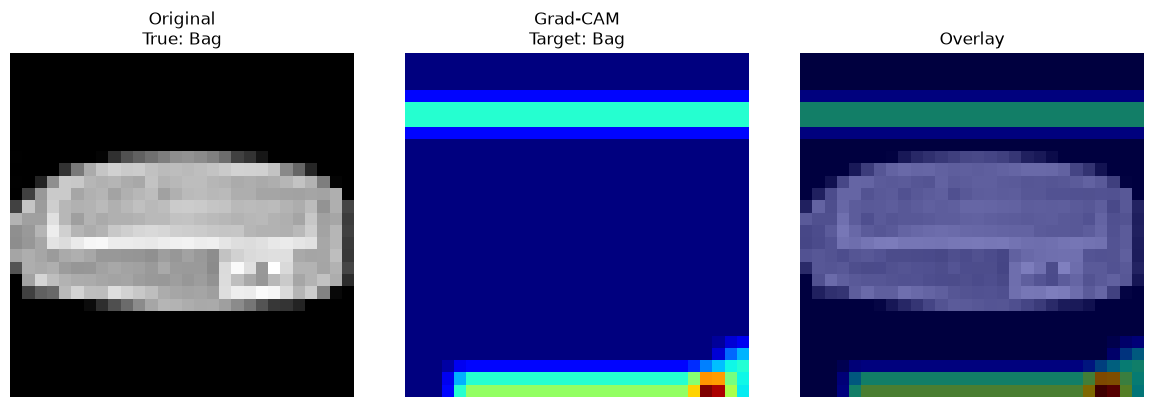

best model


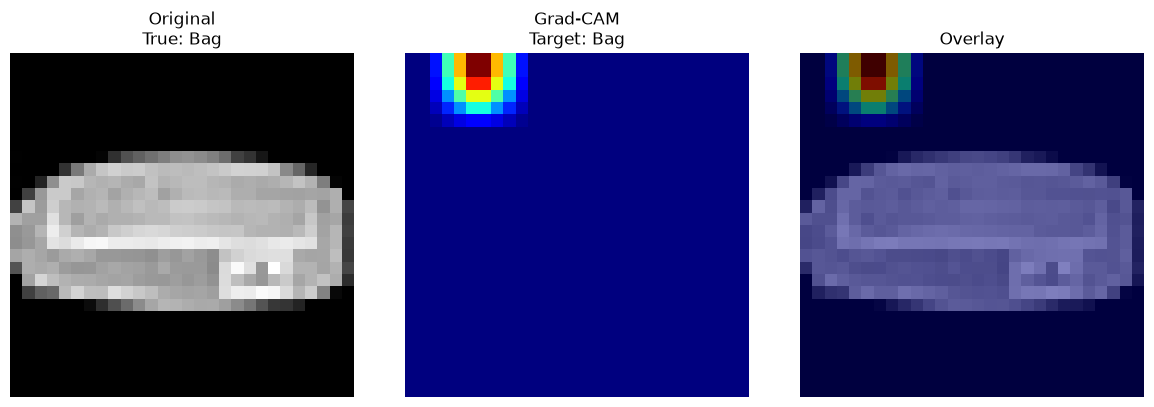

In [83]:
td = get_random_test_data()

print('1k model')
my_gradcam(
    model = model_1k,
    data_sample = td,
    target = target_1k,
    device = device
)
print('best model')
my_gradcam(
    model = best_model,
    data_sample = td,
    target = target_best,
    device = device
)

In [87]:
best_model

my_best_CNN_model(
  (layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [88]:
new_target_best = best_model.layers[18]

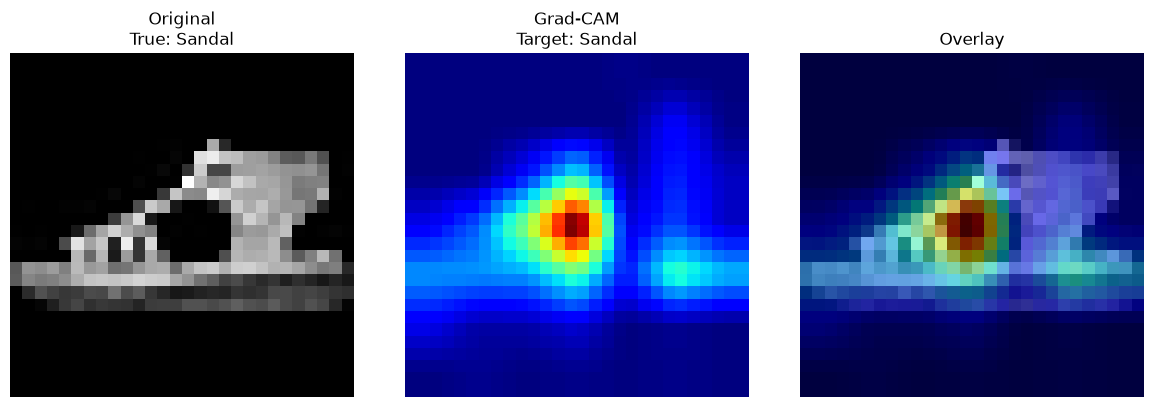

In [89]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

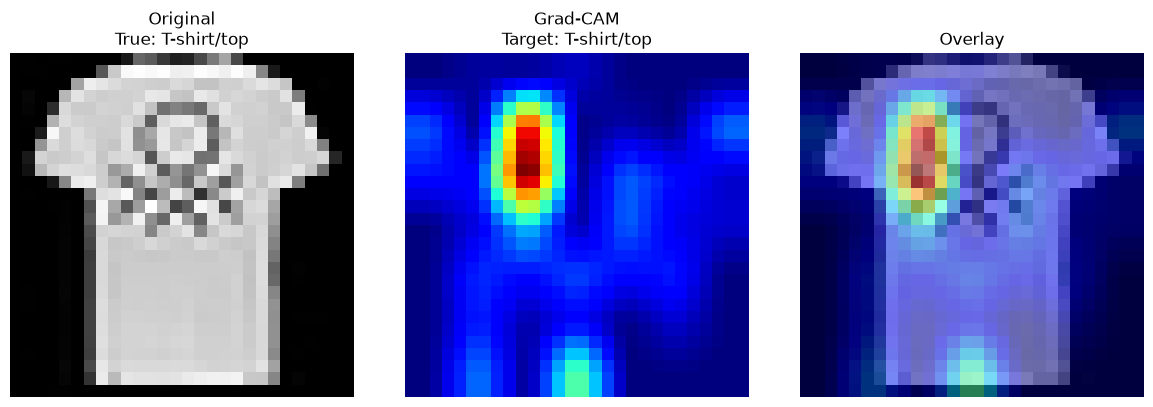

In [90]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

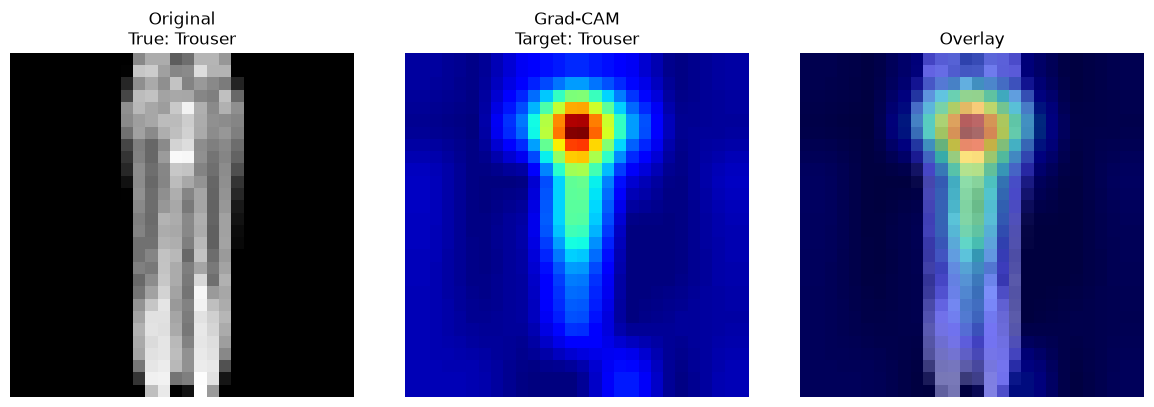

In [91]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

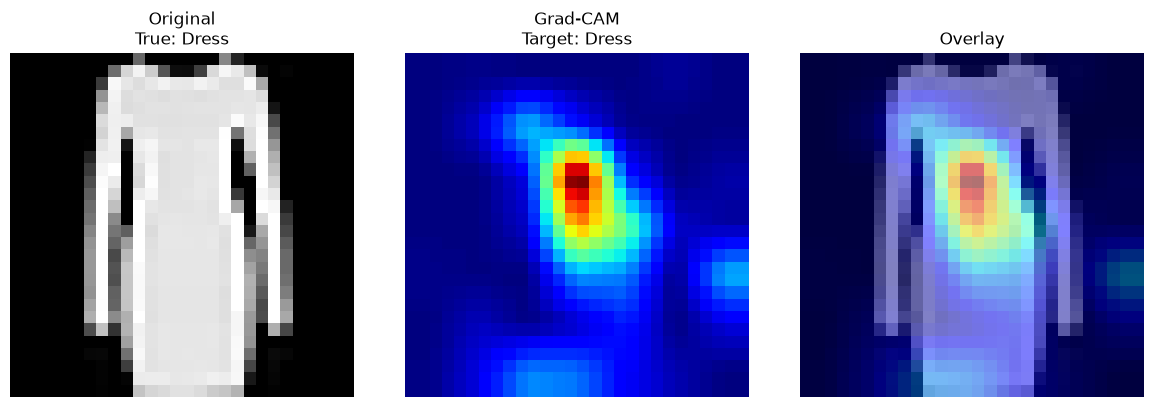

In [92]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

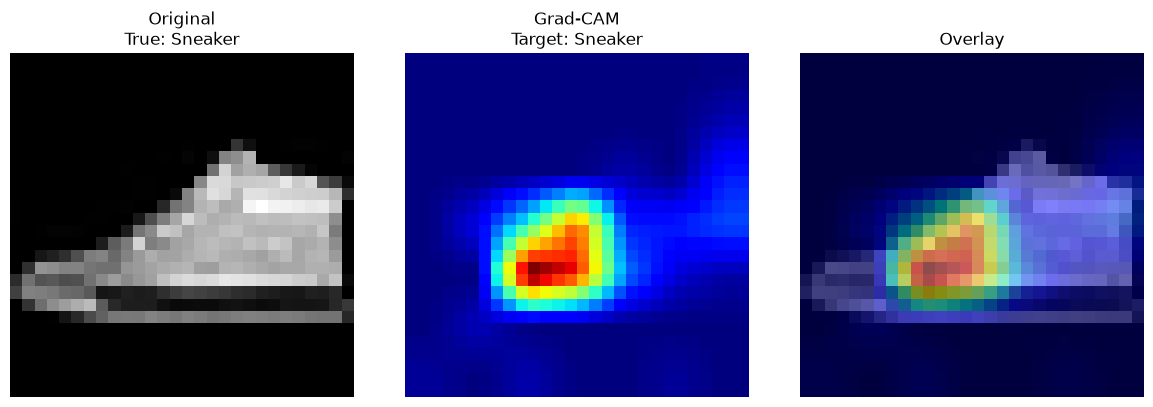

In [93]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

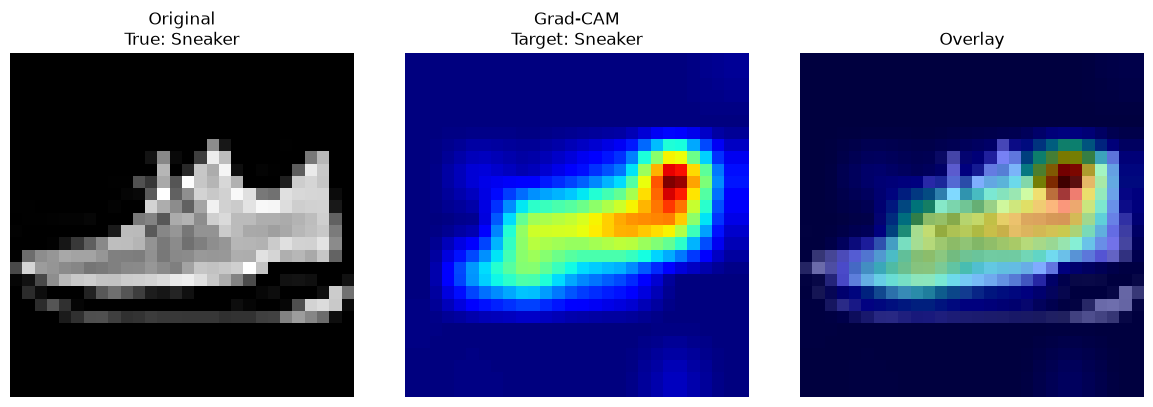

In [94]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)

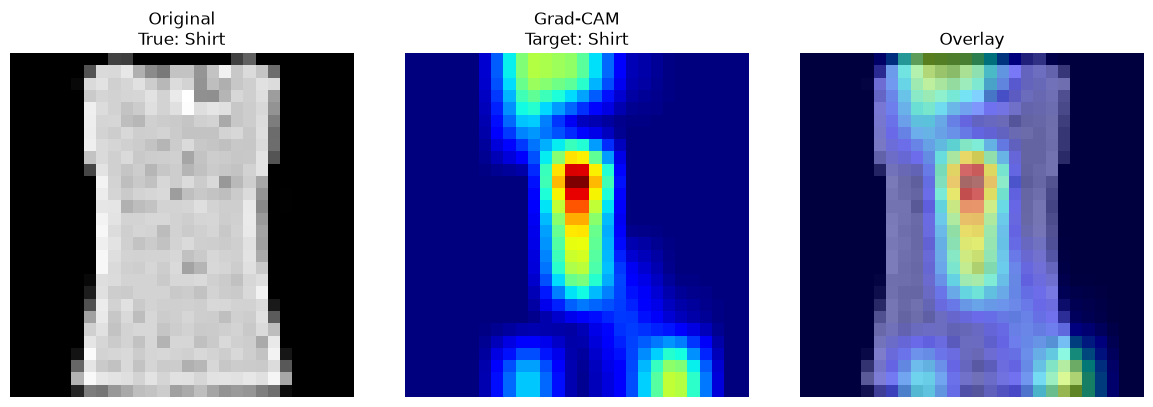

In [95]:
my_gradcam(
    model = best_model,
    data_sample = get_random_test_data(),
    target = new_target_best,
    device = device
)